# 🔬 Análisis Completo Integrado — Jerarquía de Exogeneidad
## Riesgo País Argentino — ARDL → VAR → VECM

**Enfoque:**
1. Leer las variables del CSV de análisis
2. **ARDL exhaustivo**: probar TODAS las variables como dependientes e independientes
3. Construir un **ranking de exogeneidad** (p-values, BIC, R² adj)
4. **VAR**: verificar el ranking con Granger, IRF y FEVD
5. **VECM**: captar la dinámica de largo plazo (cointegración)
6. Síntesis: identificar push factors vs pull factors idiosincráticos

---
**Solo editar la Sección 3 (CONFIGURACIÓN).**

> 📝 **Guía de referencia**: `docs/guia_02b_analisis_completo.md`

## 1. Instalación e Imports

In [1]:
import subprocess, sys, os, re

def _install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for _pkg in ['statsmodels', 'scipy', 'scikit-learn', 'openpyxl', 'matplotlib', 'numpy', 'pandas', 'ipywidgets']:
    try:
        __import__(_pkg.replace('-', '_'))
    except ImportError:
        print(f'Instalando {_pkg}...')
        _install(_pkg)

%matplotlib inline

import warnings
import glob
import random
from itertools import combinations
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..').resolve()))
from src.utils import test_estacionariedad, test_causalidad_granger, resumen_estadistico

print('Módulos cargados.')


Instalando scikit-learn...
Módulos cargados.


## 2. Funciones Auxiliares

In [2]:
# ── Directorios base (igual que generar_visualizador.py) ─────────────────────
VARS_DIR = (Path('..') / 'data' / 'Variables Finales').resolve()
RAW_DIR  = (Path('..') / 'data' / 'raw').resolve()

# ── 1. Parsear CATALOG desde visualizador_template.html ──────────────────────
def _parse_catalog():
    for _cand in [Path('visualizador_template.html'),
                  Path('notebooks') / 'visualizador_template.html']:
        if _cand.exists():
            html_path = _cand
            break
    else:
        raise FileNotFoundError('No se encontró visualizador_template.html')

    with open(html_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Acotar búsqueda solo a la sección CATALOG (evita falsos matches en JS posterior)
    _start = content.find('const CATALOG = [')
    _end   = content.find('\n];', _start)
    catalog_txt = content[_start:_end + 3] if _start >= 0 and _end >= 0 else content

    cat = {}
    _PREF    = {'D': 0, 'W': 1, 'M': 2, 'Q': 3, 'A': 4}
    _FREQ_RE = re.compile(r"freq\s*:\s*'([^']+)'")

    # ── Paso 1: ítems de fuente única (todos los campos en una sola línea) ────
    _SINGLE = re.compile(
        r"id\s*:\s*'([^']+)'.*?label\s*:\s*'([^']+)'.*?"
        r"file\s*:\s*'([^']+)'.*?dateCol\s*:\s*'([^']+)'.*?valCol\s*:\s*'([^']+)'"
    )
    for line in catalog_txt.splitlines():
        m = _SINGLE.search(line)
        if not m:
            continue
        cid, label, file_, dc, vc = m.groups()
        if label in cat:
            continue
        fm = _FREQ_RE.search(line)
        freq = fm.group(1) if fm else 'D'
        cat[label] = {'id': cid, 'file': file_, 'dateCol': dc, 'valCol': vc, 'freq': freq}

    # ── Paso 2: ítems multi-fuente (sources:[...] en varias líneas) ───────────
    _MULTI = re.compile(
        r"\{\s*id\s*:\s*'([^']+)'\s*,\s*label\s*:\s*'([^']+)'[^[]*?"
        r"sources\s*:\s*\[(.*?)\]",
        re.DOTALL
    )
    _SRC = re.compile(
        r"\{\s*freq\s*:\s*'([^']+)'[^}]*?"
        r"file\s*:\s*'([^']+)'[^}]*?"
        r"dateCol\s*:\s*'([^']+)'[^}]*?"
        r"valCol\s*:\s*'([^']+)'"
    )
    for m in _MULTI.finditer(catalog_txt):
        cid, label, srcs_txt = m.groups()
        if label in cat:
            continue
        srcs = [{'freq': sm.group(1), 'file': sm.group(2),
                 'dateCol': sm.group(3), 'valCol': sm.group(4)}
                for sm in _SRC.finditer(srcs_txt)]
        if not srcs:
            continue
        best = sorted(srcs, key=lambda s: _PREF.get(s['freq'], 99))[0]
        cat[label] = {
            'id'     : cid,
            'file'   : best['file'],
            'dateCol': best['dateCol'],
            'valCol' : best['valCol'],
            'freq'   : best['freq'],
            'sources': srcs,
        }

    return cat


CATALOG_VIZ = _parse_catalog()
print(f'✅ CATALOG parseado: {len(CATALOG_VIZ)} series')


# ── 2. Detección automática de frecuencia ─────────────────────────────────────
def detectar_frecuencia(df_csv):
    _ORD = {'D': 0, 'W': 1, 'M': 2, 'Q': 3, 'A': 4}
    finest = []
    for _, row in df_csv.iterrows():
        for col in ['Serie A', 'Serie B']:
            nombre = str(row.get(col, '') or '').strip()
            if not nombre or nombre in ('', '—', '-', 'nan'):
                continue
            if nombre not in CATALOG_VIZ:
                continue
            meta = CATALOG_VIZ[nombre]
            if 'sources' in meta:
                src_freqs = [s['freq'] for s in meta['sources']]
                finest.append(min(src_freqs, key=lambda f: _ORD.get(f, 99)))
            else:
                finest.append(meta.get('freq', 'D'))
    if not finest:
        return 'M'
    return max(finest, key=lambda f: _ORD.get(f, -1))


# ── 3. Resampling (media por período, igual que el visualizador JS) ───────────
def _resample_mean(serie: pd.Series, to_freq: str) -> pd.Series:
    _MAP = {'D': 'D', 'W': 'W', 'M': 'ME', 'Q': 'QE', 'A': 'YE'}
    pf = _MAP.get(to_freq, to_freq)
    try:
        return serie.resample(pf).mean()
    except ValueError:
        _MAP_OLD = {'D': 'D', 'W': 'W', 'M': 'M', 'Q': 'Q', 'A': 'A'}
        return serie.resample(_MAP_OLD.get(to_freq, to_freq)).mean()


# ── 4. Carga genérica ─────────────────────────────────────────────────────────
def _buscar_archivo(*rutas_relativas):
    for ruta in rutas_relativas:
        for base in [VARS_DIR, RAW_DIR]:
            p = base / ruta
            if p.exists():
                return p
    return None


def _match_col(wanted: str, available_cols) -> str | None:
    ws = wanted.strip()
    if ws in available_cols:
        return ws
    if wanted in available_cols:
        return wanted
    return None


def _leer_serie_csv(path: Path, col_fecha: str, col_valor: str) -> pd.Series:
    df = pd.read_csv(path, low_memory=False, encoding='utf-8-sig')
    df.columns = df.columns.str.strip()
    dc = _match_col(col_fecha, df.columns)
    vc = _match_col(col_valor, df.columns)
    if dc is None:
        raise KeyError(f'col_fecha "{col_fecha}" no encontrada en {path.name}. '
                       f'Cols: {list(df.columns[:8])}')
    if vc is None:
        raise KeyError(f'col_valor "{col_valor}" no encontrada en {path.name}. '
                       f'Cols: {list(df.columns[:8])}')
    df['_f'] = pd.to_datetime(df[dc], errors='coerce')
    df = df.dropna(subset=['_f']).set_index('_f').sort_index()
    return pd.to_numeric(df[vc], errors='coerce').dropna()


# ── 5. Deflactores ────────────────────────────────────────────────────────────
_cache_pbi = _cache_cer = _cache_tip = _cache_mep = None

def _get_pbi():
    global _cache_pbi
    if _cache_pbi is not None: return _cache_pbi
    p = _buscar_archivo('pbi_constante_2004.csv')
    if p is None: print('  ⚠️  pbi_constante_2004.csv no encontrado'); return None
    _cache_pbi = _leer_serie_csv(p, 'fecha', 'pbi'); return _cache_pbi

def _get_cer():
    global _cache_cer
    if _cache_cer is not None: return _cache_cer
    p = _buscar_archivo('cer.csv', 'bcra/cer.csv')
    if p is None: print('  ⚠️  cer.csv no encontrado'); return None
    _cache_cer = _leer_serie_csv(p, 'fecha', 'cer'); return _cache_cer

def _get_tip():
    global _cache_tip
    if _cache_tip is not None: return _cache_tip
    p = _buscar_archivo('tip_etf.csv', 'global/tip_etf.csv')
    if p is None: print('  ⚠️  tip_etf.csv no encontrado'); return None
    _cache_tip = _leer_serie_csv(p, 'fecha', 'tip_close'); return _cache_tip

def _get_mep():
    global _cache_mep
    if _cache_mep is not None: return _cache_mep
    p = _buscar_archivo('brecha_cambiaria.csv')
    if p is None: print('  ⚠️  brecha_cambiaria.csv no encontrado'); return None
    _cache_mep = _leer_serie_csv(p, 'fecha', 'mep'); return _cache_mep


def _alinear_deflactor(raw: pd.Series, frecuencia: str,
                        target_index: pd.DatetimeIndex) -> pd.Series | None:
    """
    Resamplea `raw` a `frecuencia`, luego alinea con `target_index`.
    Maneja datos de baja frecuencia (ej. PBI trimestral) rellenando con ffill+bfill
    para que no queden NaN en el rango de análisis.
    """
    al = _resample_mean(raw, frecuencia)
    # Para frecuencias más bajas que la de la serie (ej. PBI trim → mensual),
    # solo quedan datos en los períodos exactos del deflactor.
    # reindex+ffill propaga cada valor hasta el siguiente período.
    al = al.reindex(target_index, method='ffill').ffill().bfill()
    if al.isna().all():
        return None
    return al


def _aplicar_deflactor(serie: pd.Series, deflactor_name: str,
                        frecuencia: str) -> pd.Series:
    if not deflactor_name or str(deflactor_name).strip() in ('', '—', '-', 'nan'):
        return serie
    for d in str(deflactor_name).split(','):
        d = d.strip().upper()
        if not d or d in ('—', '-'): continue

        if d == 'PBI':
            raw = _get_pbi()
            if raw is None: continue
            al = _alinear_deflactor(raw, frecuencia, serie.index)
            if al is None:
                print('  ⚠️  PBI: sin superposición de fechas con la serie'); continue
            fp = al.iloc[0]
            serie = serie * fp / al

        elif d == 'CER':
            raw = _get_cer()
            if raw is None: continue
            al = _alinear_deflactor(raw, frecuencia, serie.index)
            if al is None:
                print('  ⚠️  CER: sin superposición de fechas con la serie'); continue
            lc = al.iloc[-1]
            serie = serie / al * lc

        elif d in ('TIP', 'IPC'):
            raw = _get_tip()
            if raw is None: continue
            al = _alinear_deflactor(raw, frecuencia, serie.index)
            if al is None:
                print(f'  ⚠️  {d}: sin superposición de fechas con la serie'); continue
            lt = al.iloc[-1]
            serie = serie / al * lt

        elif d == 'MEP':
            raw = _get_mep()
            if raw is None: continue
            al = _alinear_deflactor(raw, frecuencia, serie.index)
            if al is None:
                print('  ⚠️  MEP: sin superposición de fechas con la serie'); continue
            serie = serie / al

        else:
            print(f'    ⚠️  Deflactor no reconocido: "{d}"')
    return serie


# ── 6. Carga de serie desde CATALOG ──────────────────────────────────────────
def _cargar_serie_catalog(label: str, frecuencia: str,
                           fecha_inicio: str = None, fecha_fin: str = None):
    """
    Carga la serie `label` (nombre exacto del CATALOG) en la frecuencia indicada.
    Devuelve pd.Series o None si no se encuentra / hay error.
    """
    if label not in CATALOG_VIZ:
        print(f'  ⚠️  "{label}" no encontrado en CATALOG ({len(CATALOG_VIZ)} series).')
        return None

    meta  = CATALOG_VIZ[label]
    _PREF = {'D': 0, 'W': 1, 'M': 2, 'Q': 3, 'A': 4}

    if 'sources' in meta:
        srcs  = meta['sources']
        exact = [s for s in srcs if s['freq'] == frecuencia]
        src   = exact[0] if exact else sorted(srcs, key=lambda s: _PREF.get(s['freq'], 99))[0]
        file_, dc, vc = src['file'], src['dateCol'], src['valCol']
    else:
        file_, dc, vc = meta['file'], meta['dateCol'], meta['valCol']

    file_path = VARS_DIR / file_
    if not file_path.exists():
        file_path_raw = RAW_DIR / file_
        if file_path_raw.exists():
            file_path = file_path_raw
        else:
            print(f'  ⚠️  Archivo no encontrado: {VARS_DIR / file_}')
            return None

    try:
        if str(file_).endswith(('.xlsx', '.xls')):
            sheet = 'Unificado' if 'fiscal' in str(file_).lower() else 0
            df = pd.read_excel(file_path, sheet_name=sheet)
        else:
            df = pd.read_csv(file_path, low_memory=False, encoding='utf-8-sig')
    except Exception as e:
        print(f'  ⚠️  Error leyendo {file_}: {e}')
        return None

    df.columns = df.columns.str.strip()
    dc_match = _match_col(dc, df.columns)
    vc_match = _match_col(vc, df.columns)

    if dc_match is None:
        print(f'  ⚠️  dateCol "{dc}" no hallada en {file_}. Cols: {list(df.columns[:8])}')
        return None
    if vc_match is None:
        print(f'  ⚠️  valCol "{vc}" no hallada en {file_}. Cols: {list(df.columns[:8])}')
        return None

    df['_f'] = pd.to_datetime(df[dc_match], errors='coerce')
    df = df.dropna(subset=['_f']).set_index('_f').sort_index()
    serie = pd.to_numeric(df[vc_match], errors='coerce').dropna()
    serie.name = label

    if fecha_inicio: serie = serie[serie.index >= pd.Timestamp(fecha_inicio)]
    if fecha_fin:    serie = serie[serie.index <= pd.Timestamp(fecha_fin)]

    return _resample_mean(serie, frecuencia).dropna()


# ── 7. Construcción de variable desde fila CSV ────────────────────────────────
def construir_variable(row: pd.Series, frecuencia: str,
                        fecha_inicio: str, fecha_fin: str):
    """
    Interpreta una fila del CSV de análisis y devuelve (serie, etiqueta).

    Flujo:
      1. Carga Serie A desde CATALOG (por su nombre original, SIN deflactor).
      2. Aplica Deflactor A si corresponde.
      3. Carga Serie B si corresponde y aplica Deflactor B.
      4. Opera A y B según "Operación".
      5. Aplica Log y/o Diferencia sobre el resultado final.
    """
    nombre_a  = str(row.get('Serie A',   '') or '').strip()
    defl_a    = str(row.get('Deflactor A','') or '').strip()
    nombre_b  = str(row.get('Serie B',   '') or '').strip()
    defl_b    = str(row.get('Deflactor B','') or '').strip()
    operacion = str(row.get('Operación', 'Solo A') or 'Solo A').strip()
    log_flag  = str(row.get('Log', 'No') or 'No').strip().lower() not in ('no', '0', 'false', '')
    n_diff    = int(float(str(row.get('Dif.', 0) or 0) or 0))

    # Etiqueta legible: solo incluye deflactor y serie B si realmente se aplican
    _b_activo  = operacion != 'Solo A' and nombre_b not in ('', '—', '-', 'nan')
    _da_activo = defl_a not in ('', '—', '-', 'nan')
    _db_activo = _b_activo and defl_b not in ('', '—', '-', 'nan')

    etiqueta = nombre_a
    if _da_activo:    etiqueta += f'/{defl_a}'
    if _b_activo:     etiqueta += f' {operacion} {nombre_b}'
    if _db_activo:    etiqueta += f'/{defl_b}'
    if log_flag:      etiqueta  = f'log({etiqueta})'
    if n_diff > 0:    etiqueta  = ('Δ' * n_diff) + etiqueta

    # 1. Cargar Serie A (siempre por nombre original, sin deflactor)
    sa = _cargar_serie_catalog(nombre_a, frecuencia, fecha_inicio, fecha_fin)
    if sa is None:
        return None, etiqueta

    # 2. Deflactar Serie A
    sa = _aplicar_deflactor(sa, defl_a, frecuencia)
    resultado = sa.copy()

    # 3. Cargar y deflactar Serie B, luego operar con A
    if _b_activo:
        sb = _cargar_serie_catalog(nombre_b, frecuencia, fecha_inicio, fecha_fin)
        if sb is not None:
            sb    = _aplicar_deflactor(sb, defl_b, frecuencia)
            sb_al = sb.reindex(sa.index, method='ffill')
            # Normalizar el símbolo menos Unicode (U+2212) → guion ASCII
            op = operacion.replace(' ', '').replace('−', '-')
            if op == 'A-B':                      resultado = sa - sb_al
            elif op in ('A/B', 'A÷B'):            resultado = sa / sb_al
            elif op in ('(A-B)/B', '(A-B)/B'):    resultado = (sa - sb_al) / sb_al
            elif op == 'A+B':                     resultado = sa + sb_al
            elif op in ('A*B', 'A×B'):             resultado = sa * sb_al
            elif op in ('SoloB', 'B'):             resultado = sb_al.copy()

    # 4. Transformaciones finales sobre el resultado de la operación
    if log_flag:
        resultado = np.log(resultado.replace(0, np.nan))
    for _ in range(n_diff):
        resultado = resultado.diff()

    resultado = resultado.dropna()
    resultado.name = etiqueta
    return resultado, etiqueta


# ── 8. Validación rápida del CATALOG vs CSV ───────────────────────────────────
def _validar_catalog_vs_csv(df_csv):
    print('\n── Validación CATALOG vs CSV ────────────────────────────────────────')
    seen = set()
    for _, row in df_csv.iterrows():
        for col in ['Serie A', 'Serie B']:
            nombre = str(row.get(col, '') or '').strip()
            if not nombre or nombre in ('', '—', '-', 'nan') or nombre in seen:
                continue
            seen.add(nombre)
            if nombre not in CATALOG_VIZ:
                print(f'  ❌ NO en CATALOG: "{nombre}"')
                continue
            meta      = CATALOG_VIZ[nombre]
            file_name = meta.get('file', '?')
            existe    = (VARS_DIR / file_name).exists() or (RAW_DIR / file_name).exists()
            print(f'  {"✅" if existe else "⚠️ "} {nombre[:55]:<55} → {file_name}'
                  f'{"" if existe else "  (¡FALTA ARCHIVO!)"}')
    print('────────────────────────────────────────────────────────────────────\n')


print('✅ Funciones auxiliares listas.')
print(f'   VARS_DIR: {VARS_DIR}')
print(f'   RAW_DIR:  {RAW_DIR}')


✅ CATALOG parseado: 197 series
✅ Funciones auxiliares listas.
   VARS_DIR: C:\Users\Usuario\Desktop\MARTIN\ECONOMICS\TRABAJO FINAL\Trabajo\data\Variables Finales
   RAW_DIR:  C:\Users\Usuario\Desktop\MARTIN\ECONOMICS\TRABAJO FINAL\Trabajo\data\raw


## 3. ══════════ CONFIGURACIÓN ══════════
> **Esta es la única celda que necesitás editar.**

In [ ]:
# ── Archivo CSV ───────────────────────────────────────────────────────────────
# El visualizador descarga el archivo a la carpeta del navegador.
# Copiarlo a: notebooks/Variables Regresivas/
# Dejar None para que tome automáticamente el más reciente.
# Para un archivo específico usar solo el nombre: 'analisis_series_2026-05-06.csv'
CSV_ANALISIS = None   # None = el más reciente en notebooks/Variables Regresivas/

# ── Variable dependiente ──────────────────────────────────────────────────────
# Se elige en la Sección 4.5, luego de cargar y mostrar todas las series.

# ── Frecuencia ────────────────────────────────────────────────────────────────
# 'auto' = detecta la frecuencia más gruesa disponible entre todas las series
# Alternativas explícitas: 'D' 'W' 'M' 'Q' 'A'
FRECUENCIA = 'auto'

# ── Fechas ────────────────────────────────────────────────────────────────────
FECHA_INICIO = '2007-01-01'
FECHA_FIN    = '2026-03-31'

# ── Lags máximos ──────────────────────────────────────────────────────────────
MAX_LAGS_DEP = 4   # rezagos Y en ARDL
MAX_LAGS_IND = 4   # rezagos X en ARDL
MAX_LAGS_VAR = 8   # selección de rezagos en VAR/VECM

# ── Combinaciones ─────────────────────────────────────────────────────────────
# None = TODAS las combinaciones posibles de TODOS los tamaños
MAX_VARS_POR_MODELO = None   # None = sin límite (todas las variables)
MAX_COMBINACIONES   = None   # None = sin límite (todas las combinaciones)
SEMILLA             = 42

# ── Criterios de información ──────────────────────────────────────────────────
CRITERIOS_SEL = ['aic', 'bic', 'hqic']

# ── Nivel de significancia ────────────────────────────────────────────────────
NIVEL_SIG = 0.05

# Modelos a correr: ejecutar independientemente secciones 7 (ARDL), 8 (VAR), 9 (VECM)

print('✅ Configuración guardada.')

# ── Análisis de Exogeneidad (exclusivo de esta notebook) ──────────────────


# ¿Probar TODAS las variables como dependientes? (lento pero completo)
TODAS_COMO_DEPENDIENTE = True   # True = completo, False = solo EMBI como Y

# Lags para prewhitening
MAX_AR_ORDER = 4   # Orden máximo AR
MAX_MA_ORDER = 4   # Orden máximo MA

# Top N variables para VECM (usar las mejor rankeadas)
TOP_N_VECM = 5

# ── VAR: permutaciones Cholesky ─────────────────────────────────────────────
MAX_PERMUTACIONES_VAR = 500  # máximo de permutaciones Cholesky por modelo VAR
HORIZONTE_IRF = 12           # horizonte para IRFs ortogonalizadas

# ── GETS (General-to-Specific) ──────────────────────────────────────────────
GETS_ALPHA = 0.05            # nivel de significancia para eliminación GETS

print('✅ Configuración extendida guardada.')


✅ Configuración guardada.
✅ Configuración extendida guardada.


## 4. Carga y Construcción del Panel

In [4]:
random.seed(SEMILLA)
np.random.seed(SEMILLA)

# 1. Encontrar CSV ─────────────────────────────────────────────────────────────
_csv_dir = Path('Variables Regresivas')
if CSV_ANALISIS:
    _csv_path = _csv_dir / CSV_ANALISIS if not Path(CSV_ANALISIS).is_absolute() else Path(CSV_ANALISIS)
else:
    _candidates = sorted(glob.glob(str(_csv_dir / 'analisis_series_*.csv')))
    if not _candidates:
        raise FileNotFoundError(f'No encontré analisis_series_*.csv en {_csv_dir.resolve()}')
    _csv_path = Path(_candidates[-1])

print(f'📁 CSV: {_csv_path.name}')

# 2. Leer CSV ──────────────────────────────────────────────────────────────────
df_csv = pd.read_csv(_csv_path)
df_csv.columns = df_csv.columns.str.strip()
for _c in ['Deflactor A', 'Deflactor B', 'Serie B', 'Operación', 'Log']:
    if _c in df_csv.columns:
        df_csv[_c] = df_csv[_c].fillna('—').astype(str).str.strip()
if 'Dif.' in df_csv.columns:
    df_csv['Dif.'] = (pd.to_numeric(
        df_csv['Dif.'].astype(str).str.extract(r'(\d+)')[0], errors='coerce'
    ).fillna(0).astype(int))

print(f'   {len(df_csv)} variables en el CSV')
display(df_csv[['#','Serie A','Deflactor A','Serie B','Operación','Log','Dif.']].to_string())

# 3. Validar que todas las series del CSV estén en el CATALOG ─────────────────
_validar_catalog_vs_csv(df_csv)

# 4. Detectar frecuencia ───────────────────────────────────────────────────────
if FRECUENCIA == 'auto':
    FRECUENCIA_USADA = detectar_frecuencia(df_csv)
    print(f'🔍 Frecuencia auto-detectada: {FRECUENCIA_USADA}')
else:
    FRECUENCIA_USADA = FRECUENCIA
    print(f'📅 Frecuencia configurada: {FRECUENCIA_USADA}')

# 5. Construir todas las series (sin distinción Y/X) ───────────────────────────
print(f'\n⏳ Cargando series ({FECHA_INICIO} → {FECHA_FIN})...')
_series  = {}   # {etiqueta: pd.Series}
_eti_map = {}   # {índice CSV (0-based): etiqueta}

for _i, _row in df_csv.iterrows():
    try:
        _desde = str(_row.get('Desde', '') or '').strip()
        _hasta = str(_row.get('Hasta', '') or '').strip()
        _fi = _desde if _desde and _desde not in ('—', '-', 'nan') else FECHA_INICIO
        _ff = _hasta if _hasta and _hasta not in ('—', '-', 'nan') else FECHA_FIN
        # ── Filtro: frecuencia mínima mensual ──────────────────────────────────
        _FREQ_ORD = {'D': 0, 'W': 1, 'M': 2, 'Q': 3, 'A': 4}
        _MAX_FREQ = 2  # M = máxima frecuencia aceptada (menor granularidad)
        _nombre_a = str(_row.get('Serie A', '') or '').strip()
        _nombre_b = str(_row.get('Serie B', '') or '').strip()
        _skip_freq = False
        for _sname in [_nombre_a, _nombre_b]:
            if not _sname or _sname in ('', '\u2014', '-', 'nan'):
                continue
            if _sname in CATALOG_VIZ:
                _meta_f = CATALOG_VIZ[_sname]
                _freq_native = _meta_f.get('freq', 'D')
                if 'sources' in _meta_f:
                    _freq_native = min(
                        [s['freq'] for s in _meta_f['sources']],
                        key=lambda f: _FREQ_ORD.get(f, 99)
                    )
                if _FREQ_ORD.get(_freq_native, 0) > _MAX_FREQ:
                    print(f'  \u23ed\ufe0f [{_i+1}] {_sname}: freq={_freq_native} > mensual \u2192 descartada')
                    _skip_freq = True
                    break
        if _skip_freq:
            continue

        _s, _eti = construir_variable(_row, FRECUENCIA_USADA, _fi, _ff)
        if _s is not None and len(_s) >= 20:
            _series[_eti] = _s
            _eti_map[_i]  = _eti
            print(f'  ✅ [{_i+1}] {_eti[:75]}  →  {len(_s)} obs')
        else:
            print(f'  ❌ [{_i+1}] {_row["Serie A"]}: no cargó o < 20 obs')
    except Exception as _e:
        print(f'  ❌ [{_i+1}] {_row["Serie A"]}: {_e}')

if not _series:
    raise RuntimeError('No se cargó ninguna serie.')

# 6. Panel unificado ───────────────────────────────────────────────────────────
df_panel = pd.concat(list(_series.values()), axis=1).dropna()
print(f'\n✅ Panel: {df_panel.shape[0]} obs × {df_panel.shape[1]} vars')
print(f'   Período: {df_panel.index.min().date()} → {df_panel.index.max().date()}')

# 7. Lista numerada para selección de variable dependiente ────────────────────
print('\n' + '═'*70)
print('  Series disponibles — elegí la variable dependiente en la Sección 4.5')
print('═'*70)
_LISTA_SERIES = list(df_panel.columns)
for _n, _col in enumerate(_LISTA_SERIES, 1):
    print(f'  [{_n}]  {_col}')
print('═'*70)

📁 CSV: analisis_series_2026-05-14.csv
   7 variables en el CSV


'   #                             Serie A Deflactor A Serie B Operación Log  Dif.\n0  1               DXY — US Dollar Index           —       —    Solo A  No     1\n1  2         VIX — CBOE Volatility Index           —       —    Solo A  No     1\n2  3  Términos de Intercambio (base 100)           —       —    Solo A  No     1\n3  4                 EMBI+ Latinoamérica           —       —    Solo A  No     1\n4  5             Riesgo País ARG (EMBI+)           —       —    Solo A  No     1\n5  6                  ITCRM Multilateral           —       —    Solo A  No     1\n6  7                Reservas Brutas BCRA         PBI       —    Solo A  No     1'


── Validación CATALOG vs CSV ────────────────────────────────────────
  ✅ DXY — US Dollar Index                                   → dxy.csv
  ✅ VIX — CBOE Volatility Index                             → vix.csv
  ✅ Términos de Intercambio (base 100)                      → ti_mensual.csv
  ✅ EMBI+ Latinoamérica                                     → embi_latam.csv
  ✅ Riesgo País ARG (EMBI+)                                 → riesgo_pais_arg.csv
  ✅ ITCRM Multilateral                                      → itcrm_diario.csv
  ✅ Reservas Brutas BCRA                                    → 001_reservas_brutas.csv
────────────────────────────────────────────────────────────────────

🔍 Frecuencia auto-detectada: M

⏳ Cargando series (2007-01-01 → 2026-03-31)...
  ✅ [1] ΔDXY — US Dollar Index  →  230 obs
  ✅ [2] ΔVIX — CBOE Volatility Index  →  230 obs
  ✅ [3] ΔTérminos de Intercambio (base 100)  →  230 obs
  ✅ [4] ΔEMBI+ Latinoamérica  →  221 obs
  ✅ [5] ΔRiesgo País ARG (EMBI+)  →  230 obs
  ✅ [

## 4.5 ─── Seleccionar variable dependiente ───
> Corré la celda de abajo: imprime la lista y selecciona automáticamente riesgo país.  
> Si querés otra variable, cambiá el número en `VARIABLE_DEPENDIENTE` y volvé a correrla.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  ELEGÍ LA VARIABLE DEPENDIENTE — cambiá solo el número de abajo
#  y volvé a correr esta celda
# ══════════════════════════════════════════════════════════════════════════════

# Auto-detecta riesgo país; si no lo encuentra usa 1
_KEYWORDS_DEP = ['embi', 'riesgo', 'spread', 'cds', 'country risk']
_auto_idx = next(
    (i + 1 for i, c in enumerate(_LISTA_SERIES)
     if any(kw in c.lower() for kw in _KEYWORDS_DEP)),
    1
)

VARIABLE_DEPENDIENTE = _auto_idx   # ← CAMBIÁ ESTE NÚMERO SI QUERÉS OTRA VARIABLE

# ── Lista disponible ──────────────────────────────────────────────────────────
print('═' * 65)
for _i, _c in enumerate(_LISTA_SERIES, 1):
    marca = '  ◄ seleccionada' if _i == VARIABLE_DEPENDIENTE else ''
    print(f'  [{_i:>2}]  {_c}{marca}')
print('═' * 65)

# ── Aplicar selección ─────────────────────────────────────────────────────────
if not (1 <= VARIABLE_DEPENDIENTE <= len(_LISTA_SERIES)):
    raise ValueError(f'VARIABLE_DEPENDIENTE={VARIABLE_DEPENDIENTE} fuera de rango (1–{len(_LISTA_SERIES)})')

ETI_DEP  = _LISTA_SERIES[VARIABLE_DEPENDIENTE - 1]
ETI_EXPL = [c for c in _LISTA_SERIES if c != ETI_DEP]

_all_cols = [ETI_DEP] + ETI_EXPL
COL_SAFE  = {c: f'v{i:02d}' for i, c in enumerate(_all_cols)}
COL_LABEL = {v: k for k, v in COL_SAFE.items()}
df_safe   = df_panel[_all_cols].rename(columns=COL_SAFE)
Y_SAFE    = COL_SAFE[ETI_DEP]
X_SAFE    = [COL_SAFE[e] for e in ETI_EXPL]

print(f'\n✅ Y = {ETI_DEP}')
print(f'   {len(ETI_EXPL)} variables explicativas')


═════════════════════════════════════════════════════════════════
  [ 1]  ΔDXY — US Dollar Index
  [ 2]  ΔVIX — CBOE Volatility Index
  [ 3]  ΔTérminos de Intercambio (base 100)
  [ 4]  ΔEMBI+ Latinoamérica  ◄ seleccionada
  [ 5]  ΔRiesgo País ARG (EMBI+)
  [ 6]  ΔITCRM Multilateral
  [ 7]  ΔReservas Brutas BCRA/PBI
═════════════════════════════════════════════════════════════════

✅ Y = ΔEMBI+ Latinoamérica
   6 variables explicativas


## 5. Estadísticos Descriptivos

,N,Inicio,Fin,Media,Mediana,Desvío,Min,Max,Asimetría,Curtosis,Jarque-Bera (p)
ΔDXY — US Dollar Index,221,2007-11-30,2026-03-31,0.097893,0.107391,1.573902,-3.801428,4.847454,0.054793,0.224525,0.798461
ΔVIX — CBOE Volatility Index,221,2007-11-30,2026-03-31,0.029327,-0.254809,5.019412,-16.283009,38.107871,3.082316,21.330249,0.0
ΔTérminos de Intercambio (base 100),221,2007-11-30,2026-03-31,0.141674,0.234561,4.626858,-13.65165,12.625256,0.031297,0.232199,0.817199
ΔEMBI+ Latinoamérica,221,2007-11-30,2026-03-31,0.003201,-0.036112,0.377206,-0.924993,2.894234,3.223493,22.336501,0.0
ΔRiesgo País ARG (EMBI+),221,2007-11-30,2026-03-31,0.975265,-3.945455,191.461628,-788.636559,1329.371524,1.638169,13.383151,0.0
ΔITCRM Multilateral,221,2007-11-30,2026-03-31,-0.325629,-0.711089,4.948605,-17.032856,41.675946,3.388406,26.127004,0.0
ΔReservas Brutas BCRA/PBI,221,2007-11-30,2026-03-31,-23.059189,195.472319,2311.018354,-8964.850295,8984.067702,-0.381207,2.5127,0.0


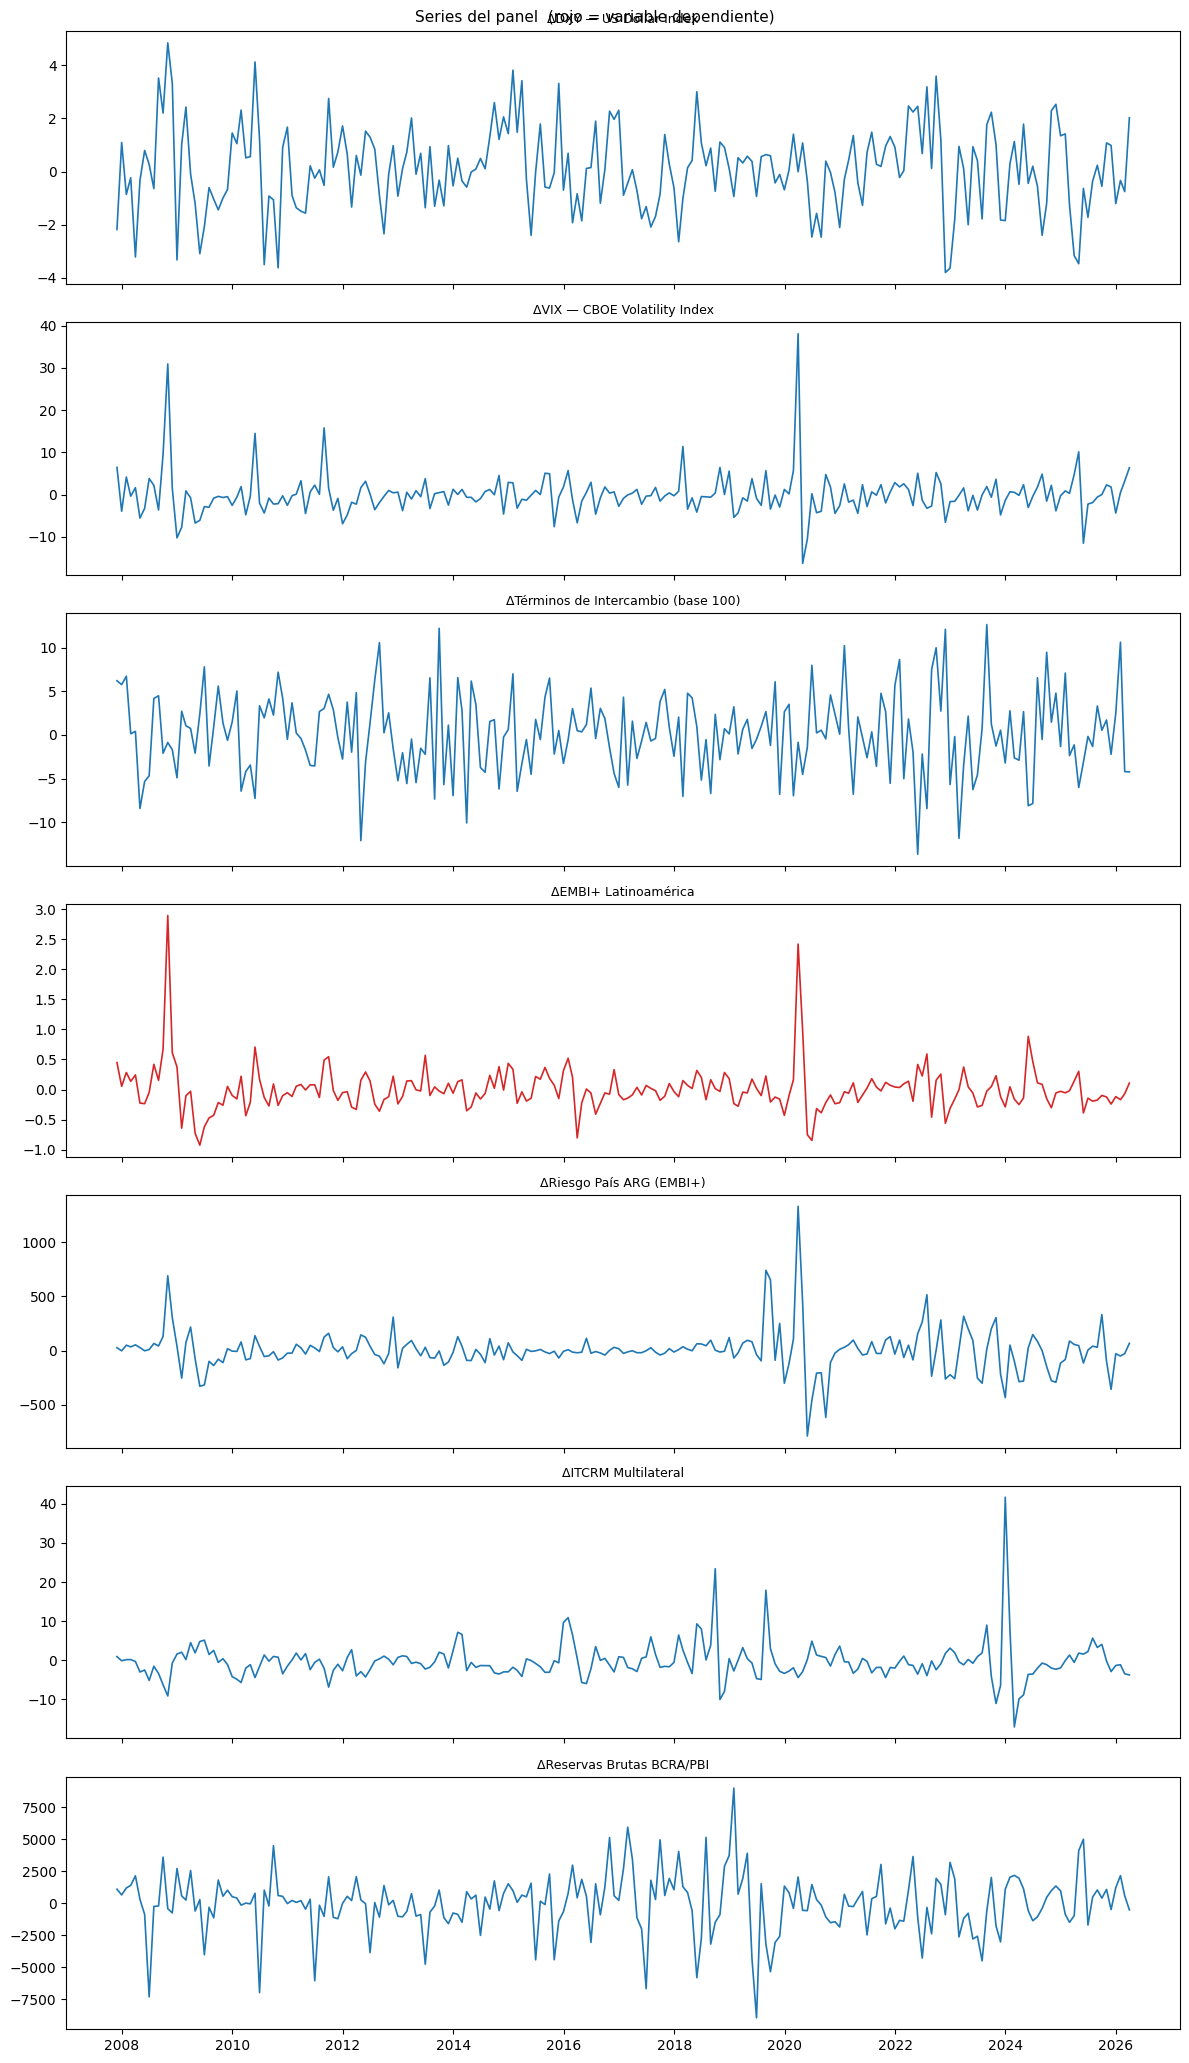

In [6]:
display(resumen_estadistico(df_panel).round(4))

n_series = len(df_panel.columns)
fig, axes = plt.subplots(n_series, 1, figsize=(12, 3 * n_series), sharex=True, squeeze=False)

for i, col in enumerate(df_panel.columns):
    color = '#d62728' if col == ETI_DEP else '#1f77b4'
    axes[i][0].plot(df_panel.index, df_panel[col], color=color, linewidth=1.2)
    axes[i][0].set_title(col, fontsize=9)

fig.suptitle('Series del panel  (rojo = variable dependiente)', fontsize=11)
plt.tight_layout()
plt.show()


## 6. Tests de Estacionariedad

In [7]:
# ── Tests ADF + KPSS ──────────────────────────────────────────────────────────
print('═'*70)
print('6.  TESTS DE ESTACIONARIEDAD (ADF + KPSS)')
print('═'*70)
_est_rows = []
for _col in df_panel.columns:
    _r = test_estacionariedad(df_panel[_col], _col)
    _est_rows.append(_r)
df_est = pd.DataFrame(_est_rows).set_index('Variable')
display(df_est[['ADF_stat','ADF_pvalue','ADF_estacionaria',
                'KPSS_stat','KPSS_pvalue','KPSS_estacionaria','Conclusión']])

# ── Identificar series no estacionarias ───────────────────────────────────────
_non_stat_labels = set(
    df_est.index[df_est['Conclusión'].isin(['No Estacionaria', 'Conflicto'])]
)

# Diccionario safe_name -> label de las no estacionarias (excluyendo dep. variable)
VARS_NO_ESTACIONARIAS = {
    _s: COL_LABEL.get(_s, _s)
    for _s in X_SAFE
    if COL_LABEL.get(_s, _s) in _non_stat_labels
}

# Variables explicativas disponibles para estimación (solo estacionarias)
X_SAFE_EST = [v for v in X_SAFE if v not in VARS_NO_ESTACIONARIAS]

# ── Aviso al usuario ───────────────────────────────────────────────────────────
if VARS_NO_ESTACIONARIAS:
    _dep_non_stat = ETI_DEP in _non_stat_labels
    print('\n' + '='*70)
    print('  ADVERTENCIA - VARIABLES NO ESTACIONARIAS DETECTADAS')
    print('='*70)
    if _dep_non_stat:
        print(f'\n  La variable dependiente "{ETI_DEP}" no es estacionaria.')
        print('  Considere transformarla (diferencias, log) antes de estimar.')
    print(f'\n  Variables explicativas no estacionarias ({len(VARS_NO_ESTACIONARIAS)}):')
    for _s, _l in VARS_NO_ESTACIONARIAS.items():
        print(f'    - {_l}')
    print()
    print('  Estas variables seran DESCARTADAS automaticamente de las regresiones.')
    print('  Para incluirlas, aplique una transformacion (delta, log, log-delta, etc.)')
    print('  y vuelva a correr desde la Seccion 4 con los datos transformados.')
    print('='*70)
else:
    print('\nTodas las variables son estacionarias. Puede proceder con las estimaciones.')

print(f'\nVariables para estimacion: {len(X_SAFE_EST)} de {len(X_SAFE)} explicativas disponibles.')
if VARS_NO_ESTACIONARIAS:
    print(f'Descartadas: {", ".join(VARS_NO_ESTACIONARIAS.values())}')
print('\nTests de estacionariedad completados.')


══════════════════════════════════════════════════════════════════════
6.  TESTS DE ESTACIONARIEDAD (ADF + KPSS)
══════════════════════════════════════════════════════════════════════


C:\Users\Usuario\Desktop\MARTIN\ECONOMICS\TRABAJO FINAL\Trabajo\src\utils.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(serie_clean, regression='c', nlags='auto')
C:\Users\Usuario\Desktop\MARTIN\ECONOMICS\TRABAJO FINAL\Trabajo\src\utils.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(serie_clean, regression='c', nlags='auto')
C:\Users\Usuario\Desktop\MARTIN\ECONOMICS\TRABAJO FINAL\Trabajo\src\utils.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(serie_clean, regression='c', nlags='auto')
C:\Users\Usuario\Desktop\MARTIN\ECONOMICS\TRABAJO FINAL\Trabajo\

,ADF_stat,ADF_pvalue,ADF_estacionaria,KPSS_stat,KPSS_pvalue,KPSS_estacionaria,Conclusión
Variable,,,,,,,
ΔDXY — US Dollar Index,-10.5856,0.0000,True,0.0413,0.1,True,✅ Estacionaria
ΔVIX — CBOE Volatility Index,-7.2002,0.0000,True,0.0415,0.1,True,✅ Estacionaria
ΔTérminos de Intercambio (base 100),-7.8530,0.0000,True,0.0254,0.1,True,✅ Estacionaria
ΔEMBI+ Latinoamérica,-9.6387,0.0000,True,0.0562,0.1,True,✅ Estacionaria
ΔRiesgo País ARG (EMBI+),-11.8224,0.0000,True,0.0859,0.1,True,✅ Estacionaria
ΔITCRM Multilateral,-12.2102,0.0000,True,0.0979,0.1,True,✅ Estacionaria
ΔReservas Brutas BCRA/PBI,-3.1384,0.0238,True,0.0678,0.1,True,✅ Estacionaria



Todas las variables son estacionarias. Puede proceder con las estimaciones.

Variables para estimacion: 6 de 6 explicativas disponibles.

Tests de estacionariedad completados.


### 7.1b Prewhitening Box-Jenkins (todas las combinaciones Y/X)

> Para cada par `(Y_i, X_j)`: ajustar ARMA a X_j, filtrar Y_i, calcular CCF.
> Esto genera los lags optimos para cada combinacion de variables.


### 7.1a Estructuras ARMA Individuales

> Ajustar `auto_arima` a cada variable para identificar su estructura ARMA(p,q) optima.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# 7.1a  ESTRUCTURAS ARMA INDIVIDUALES (auto_arima)
# ═══════════════════════════════════════════════════════════════════════════

try:
    from pmdarima import auto_arima as _auto_arima_ind
except ImportError:
    import subprocess as _sp_ind, sys as _sys_ind
    _sp_ind.check_call([_sys_ind.executable, '-m', 'pip', 'install', 'pmdarima', '-q'])
    from pmdarima import auto_arima as _auto_arima_ind

print('═'*70)
print('7.1a  ESTRUCTURAS ARMA INDIVIDUALES (auto_arima)')
print('═'*70)

arma_orders = {}

for _v in df_safe.columns:
    _s = df_safe[_v].dropna()
    if len(_s) < 20:
        print(f'  ⚠️  {COL_LABEL.get(_v, _v)[:40]:<40}  n={len(_s)} insuficiente')
        arma_orders[_v] = {'order': (0, 0), 'aic': np.nan}
        continue
    try:
        _fit = _auto_arima_ind(
            _s.values, information_criterion='aic',
            stepwise=True, seasonal=False, d=0,
            max_p=MAX_AR_ORDER, max_q=MAX_MA_ORDER,
            suppress_warnings=True, error_action='ignore',
        )
        _p, _, _q = _fit.order
        _aic = _fit.aic() if hasattr(_fit, 'aic') and callable(_fit.aic) else getattr(_fit, 'aic', np.nan)
        arma_orders[_v] = {'order': (_p, _q), 'aic': _aic}
        print(f'  ✅ {COL_LABEL.get(_v, _v)[:40]:<40}  ARMA({_p},{_q})  AIC={_aic:.2f}')
    except Exception as _e:
        print(f'  ❌ {COL_LABEL.get(_v, _v)[:40]:<40}  error: {_e}')
        arma_orders[_v] = {'order': (0, 0), 'aic': np.nan}

_n_found = sum(1 for v in arma_orders if arma_orders[v]['order'] != (0, 0))
print(f'Estructuras ARMA identificadas: {_n_found} / {len(df_safe.columns)} variables')


══════════════════════════════════════════════════════════════════════
7.1a  ESTRUCTURAS ARMA INDIVIDUALES (auto_arima)
══════════════════════════════════════════════════════════════════════
  ✅ ΔEMBI+ Latinoamérica                      ARMA(0,1)  AIC=167.12
  ✅ ΔDXY — US Dollar Index                    ARMA(1,0)  AIC=806.87
  ✅ ΔVIX — CBOE Volatility Index              ARMA(1,2)  AIC=1324.80
  ✅ ΔTérminos de Intercambio (base 100)       ARMA(2,3)  AIC=1285.95
  ✅ ΔRiesgo País ARG (EMBI+)                  ARMA(2,2)  AIC=2914.06
  ✅ ΔITCRM Multilateral                       ARMA(0,3)  AIC=1313.51
  ✅ ΔReservas Brutas BCRA/PBI                 ARMA(3,1)  AIC=4032.15
Estructuras ARMA identificadas: 7 / 7 variables


══════════════════════════════════════════════════════════════════════
7.1b  PREWHITENING + CCF — TODAS LAS COMBINACIONES (Y_i, X_j)
══════════════════════════════════════════════════════════════════════
  [ 1/7] ΔEMBI+ Latinoamérica                     → 6 pares
  [ 2/7] ΔDXY — US Dollar Index                   → 6 pares
  [ 3/7] ΔVIX — CBOE Volatility Index             → 6 pares
  [ 4/7] ΔTérminos de Intercambio (base 100)      → 6 pares
  [ 5/7] ΔRiesgo País ARG (EMBI+)                 → 6 pares
  [ 6/7] ΔITCRM Multilateral                      → 6 pares
  [ 7/7] ΔReservas Brutas BCRA/PBI                → 6 pares
Pares analizados exitosamente: 42 / 42


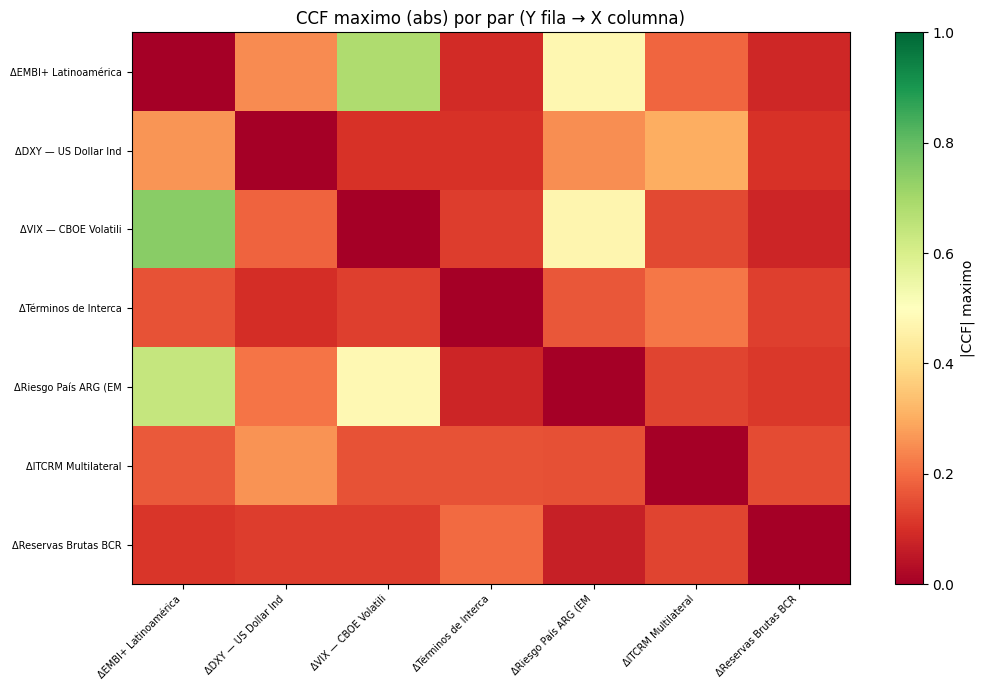

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# 7.1b  PREWHITENING + CCF — TODAS LAS COMBINACIONES (Y_i, X_j)
# ═══════════════════════════════════════════════════════════════════════════
from statsmodels.tsa.arima.model import ARIMA as _ARIMA_mod
from statsmodels.tsa.stattools import ccf as _ccf_fn

print('═'*70)
print('7.1b  PREWHITENING + CCF — TODAS LAS COMBINACIONES (Y_i, X_j)')
print('═'*70)

bj_lags = {}

_ccf_nlags = MAX_LAGS_VAR
_z_ci = 1.96

ALL_VARS = [Y_SAFE] + X_SAFE_EST if not TODAS_COMO_DEPENDIENTE else list(df_safe.columns)

_n_pairs_ok = 0

for _yi, _yvar in enumerate(ALL_VARS):
    _y_s = df_safe[_yvar].dropna()
    for _xj, _xvar in enumerate(ALL_VARS):
        if _xvar == _yvar:
            continue
        
        _x_s = df_safe[_xvar].dropna()
        _df_xy = pd.concat([_y_s.rename('y'), _x_s.rename('x')], axis=1).dropna()
        
        if len(_df_xy) < 30:
            bj_lags[(_yvar, _xvar)] = {'lags': [0, 1], 'ccf_max': 0.0, 'arma_order': (0, 0), 'raw': True}
            continue
        
        _arma_info = arma_orders.get(_xvar, {'order': (0, 0)})
        _p_ord, _q_ord = _arma_info['order']
        _p_ord = min(_p_ord, MAX_AR_ORDER)
        _q_ord = min(_q_ord, MAX_MA_ORDER)
        
        try:
            if _p_ord == 0 and _q_ord == 0:
                _x_w = _df_xy['x'].values
                _y_w = _df_xy['y'].values
                _raw = True
            else:
                _fit_x = _ARIMA_mod(_df_xy['x'].values, order=(_p_ord, 0, _q_ord)).fit()
                _x_resid = _fit_x.resid
                _ar_coefs = _fit_x.arparams if hasattr(_fit_x, 'arparams') and len(_fit_x.arparams) > 0 else []
                
                _y_arr = _df_xy['y'].values
                if len(_ar_coefs) > 0:
                    _p_ar = len(_ar_coefs)
                    _y_filt = np.array([
                        _y_arr[t] - np.dot(_ar_coefs, _y_arr[t - _p_ar:t][::-1])
                        for t in range(_p_ar, len(_y_arr))
                    ])
                else:
                    _y_filt = _y_arr.copy()
                
                _n_min = min(len(_x_resid), len(_y_filt))
                _x_w = _x_resid[-_n_min:]
                _y_w = _y_filt[-_n_min:]
                _raw = False
            
            _nlags_actual = min(_ccf_nlags, len(_x_w) // 3)
            _ci = _z_ci / np.sqrt(len(_x_w))
            _ccf_vals = _ccf_fn(_x_w, _y_w, nlags=_nlags_actual, alpha=None)
            
            _sig_lags = [int(l) for l in range(len(_ccf_vals)) if abs(_ccf_vals[l]) > _ci]
            _prop_lags = sorted({l for l in _sig_lags if 0 <= l <= MAX_LAGS_IND})
            if not _prop_lags:
                _prop_lags = [0, 1]
            
            _ccf_max = max(abs(_ccf_vals)) if len(_ccf_vals) > 0 else 0.0
            
            bj_lags[(_yvar, _xvar)] = {
                'lags': _prop_lags,
                'ccf_max': _ccf_max,
                'arma_order': (_p_ord, _q_ord),
                'raw': _raw,
            }
            _n_pairs_ok += 1
            
        except Exception as _e:
            bj_lags[(_yvar, _xvar)] = {'lags': [0, 1], 'ccf_max': 0.0, 'arma_order': (_p_ord, _q_ord), 'raw': True}
    
    _y_label = COL_LABEL.get(_yvar, _yvar)
    print(f'  [{_yi+1:>2}/{len(ALL_VARS)}] {_y_label[:40]:<40} → {len(ALL_VARS)-1} pares')

print(f'Pares analizados exitosamente: {_n_pairs_ok} / {len(ALL_VARS) * (len(ALL_VARS) - 1)}')

# Heatmap N×N
if bj_lags:
    _n = len(ALL_VARS)
    _mat = np.zeros((_n, _n))
    for i, _yv in enumerate(ALL_VARS):
        for j, _xv in enumerate(ALL_VARS):
            if _yv == _xv:
                _mat[i, j] = 0
            else:
                _mat[i, j] = bj_lags.get((_yv, _xv), {}).get('ccf_max', 0)
    
    fig, ax = plt.subplots(figsize=(max(6, _n*1.5), max(5, _n*1.0)))
    _labels_short = [COL_LABEL.get(v, v)[:20] for v in ALL_VARS]
    _im = ax.imshow(_mat, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(_n))
    ax.set_yticks(range(_n))
    ax.set_xticklabels(_labels_short, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(_labels_short, fontsize=7)
    ax.set_title('CCF maximo (abs) por par (Y fila → X columna)')
    plt.colorbar(_im, ax=ax, label='|CCF| maximo')
    plt.tight_layout()
    plt.show()


### 7.2 Estimaciones ARDL — Todas las combinaciones posibles

> Cada variable se prueba como dependiente. Para cada Y_i, se estiman ARDL
> con todas las combinaciones de las demás variables como explicativas.

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# 7.2  ESTIMACIONES ARDL EXHAUSTIVAS + DIAGNOSTICOS DE RESIDUOS
# ═══════════════════════════════════════════════════════════════════════════
from itertools import combinations
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tsa.stattools import acf

# Importar tests de autocorrelacion con fallback
try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    _has_ljungbox = True
except ImportError:
    _has_ljungbox = False
try:
    from statsmodels.stats.diagnostic import acorr_breusch_godfrey
    _has_bg = True
except ImportError:
    _has_bg = False

print('═'*70)
print('7.2  ESTIMACIONES ARDL — TODAS LAS VARIABLES COMO DEPENDIENTES')
print('═'*70)

_y_vars = ALL_VARS if TODAS_COMO_DEPENDIENTE else [Y_SAFE]
results_list = []

_total_models = 0
for _yvar in _y_vars:
    _other = [v for v in ALL_VARS if v != _yvar]
    _all_combos = []
    for k in range(1, len(_other) + 1):
        if MAX_VARS_POR_MODELO is not None and k > MAX_VARS_POR_MODELO:
            continue
        _all_combos.extend(list(combinations(_other, k)))
    
    if MAX_COMBINACIONES is not None and len(_all_combos) > MAX_COMBINACIONES:
        random.seed(SEMILLA)
        _all_combos = random.sample(_all_combos, MAX_COMBINACIONES)
    
    print(f'  {COL_LABEL.get(_yvar, _yvar)[:40]:<40} → {len(_all_combos)} combinaciones')
    
    import itertools
    for _combo in _all_combos:
        _lag_combinations = list(itertools.product(range(1, MAX_LAGS_DEP + 1), repeat=len(_combo) + 1))
        for _lags in _lag_combinations:
            try:
                _y_lag = _lags[0]
                _x_lags = _lags[1:]
                _df_reg = pd.DataFrame({'y': df_safe[_yvar]})
                
                # Rezagos de Y
                for lag in range(1, _y_lag + 1):
                    _df_reg[f'{_yvar}_L{lag}'] = df_safe[_yvar].shift(lag)
                
                # Rezagos de X
                for _idx, _xvar in enumerate(_combo):
                    for lag in range(1, _x_lags[_idx] + 1):
                        _df_reg[f'{_xvar}_L{lag}'] = df_safe[_xvar].shift(lag)
            
            _df_reg = _df_reg.dropna()
            if len(_df_reg) < 20:
                continue
            
            _y_vals = _df_reg['y']
            _X_vals = _df_reg.drop(columns=['y'])
            _X_vals = sm.add_constant(_X_vals)
            
            # Evitar rank deficiency
            if np.linalg.matrix_rank(_X_vals) < _X_vals.shape[1]:
                continue
            
            _model = sm.OLS(_y_vals, _X_vals).fit()
            _resid = _model.resid
            
            # ── Diagnosticos ──
            _dw = durbin_watson(_resid)
            
            # Ljung-Box
            _lb_p = np.nan
            if _has_ljungbox:
                try:
                    _lb_lags = min(10, len(_resid) // 5)
                    _lb_res = acorr_ljungbox(_resid, lags=_lb_lags, return_df=True)
                    if hasattr(_lb_res, 'columns'):
                        if 'lb_pvalue' in _lb_res.columns:
                            _lb_p = _lb_res['lb_pvalue'].iloc[-1]
                        elif 'pvalue' in _lb_res.columns:
                            _lb_p = _lb_res['pvalue'].iloc[-1]
                    elif isinstance(_lb_res, tuple):
                        _lb_p = _lb_res[1][-1]
                except Exception:
                    _lb_p = np.nan
            
            # Breusch-Godfrey
            _bg_p = np.nan
            if _has_bg:
                try:
                    _bg_lags = min(MAX_LAGS_VAR, len(_resid) // 5)
                    _bg_res = acorr_breusch_godfrey(_model, nlags=_bg_lags)
                    _bg_p = _bg_res[1]
                except Exception:
                    _bg_p = np.nan
            
            # Jarque-Bera
            try:
                _jb_res = jarque_bera(_resid)
                _jb_p = _jb_res[1]
            except Exception:
                _jb_p = np.nan
            
            _is_white = (_lb_p >= 0.05) and (_bg_p >= 0.05)
            
            # Orden AR en residuos (si no es ruido blanco)
            _resid_ar = None
            if not _is_white:
                try:
                    _acf_resid = acf(_resid, nlags=MAX_AR_ORDER, fft=False)
                    _sig_count = sum(1 for i in range(1, len(_acf_resid)) if abs(_acf_resid[i]) > 1.96/np.sqrt(len(_resid)))
                    _resid_ar = _sig_count if _sig_count > 0 else None
                except Exception:
                    _resid_ar = None
            
            # Coeficientes y p-values (excluyendo constante)
            _coefs = {}
            _pvals = {}
            for _col in _X_vals.columns:
                if _col == 'const':
                    continue
                _coefs[_col] = _model.params[_col]
                _pvals[_col] = _model.pvalues[_col]
            
            results_list.append({
                'y_var': _yvar,
                'x_vars': _combo,
                'n_vars': len(_combo),
                'R2_adj': _model.rsquared_adj,
                'AIC': _model.aic,
                'BIC': _model.bic,
                'HQ': getattr(_model, 'hqic', np.nan),
                'coefs': _coefs,
                'pvalues': _pvals,
                'n_obs': len(_df_reg),
                'DW': _dw,
                'LB_pvalue': _lb_p,
                'BG_pvalue': _bg_p,
                'JB_pvalue': _jb_p,
                'resid_ruido_blanco': _is_white,
                'resid_AR_order': _resid_ar,
            })
            _total_models += 1
            
        except Exception:
            continue

df_ardl_full = pd.DataFrame(results_list)

print(f'\nModelos estimados: {len(df_ardl_full)}')
if not df_ardl_full.empty:
    _n_white = df_ardl_full['resid_ruido_blanco'].sum()
    print(f'Modelos con residuos de ruido blanco: {_n_white} ({_n_white/len(df_ardl_full)*100:.1f}%)')
    
    _df_white = df_ardl_full[df_ardl_full['resid_ruido_blanco'] == True]
    if not _df_white.empty:
        _r2_media = _df_white['R2_adj'].mean()
        _bic_media_white = _df_white['BIC'].mean()
        print(f'  -> R2_adj medio (ruido blanco): {_r2_media:.4f}')
        print(f'  -> BIC medio (ruido blanco):    {_bic_media_white:.2f}')
    
    print('\n' + '═'*70)
    print('  RESUMEN DE DIAGNOSTICOS POR VARIABLE DEPENDIENTE')
    print('═'*70)
    _diag_summary = df_ardl_full.groupby('y_var').agg({
        'R2_adj': 'mean',
        'BIC': 'mean',
        'resid_ruido_blanco': 'sum',
        'n_vars': 'count',
    }).rename(columns={'resid_ruido_blanco': 'n_ruido_blanco', 'n_vars': 'n_modelos'})
    _diag_summary.index = [COL_LABEL.get(v, v)[:40] for v in _diag_summary.index]
    print(_diag_summary.round(4).to_string())
    print('═'*70)
else:
    print('⚠️  No se estimo ningún modelo.')


══════════════════════════════════════════════════════════════════════
7.2  ESTIMACIONES ARDL — TODAS LAS VARIABLES COMO DEPENDIENTES
══════════════════════════════════════════════════════════════════════
  ΔEMBI+ Latinoamérica                     → 63 combinaciones
  ΔDXY — US Dollar Index                   → 63 combinaciones
  ΔVIX — CBOE Volatility Index             → 63 combinaciones
  ΔTérminos de Intercambio (base 100)      → 63 combinaciones
  ΔRiesgo País ARG (EMBI+)                 → 63 combinaciones
  ΔITCRM Multilateral                      → 63 combinaciones
  ΔReservas Brutas BCRA/PBI                → 63 combinaciones

Modelos estimados: 441
Modelos con residuos de ruido blanco: 287 (65.1%)
  -> R2_adj medio (ruido blanco): 0.2624
  -> BIC medio (ruido blanco):    1656.95

══════════════════════════════════════════════════════════════════════
  RESUMEN DE DIAGNOSTICOS POR VARIABLE DEPENDIENTE
══════════════════════════════════════════════════════════════════════
          

### 7.3 Construcción de la Jerarquía de Exogeneidad

> Score compuesto: p-value promedio como X × R² invertido como Y × frecuencia de significancia × parsimonia BIC.
> Mayor score = variable más exógena.

══════════════════════════════════════════════════════════════════════
7.3  RANKING DE EXOGENEIDAD
══════════════════════════════════════════════════════════════════════

Modelos validos (ruido blanco + BIC < media): 204 de 441
Variables analizadas: 7

══════════════════════════════════════════════════════════════════════
  RANKING DE EXOGENEIDAD
══════════════════════════════════════════════════════════════════════
  [ 1]  ΔDXY — US Dollar Index                                   score=3.1955
  [ 2]  ΔITCRM Multilateral                                      score=2.2966
  [ 3]  ΔRiesgo País ARG (EMBI+)                                 score=1.7500
  [ 4]  ΔEMBI+ Latinoamérica                                     score=1.4726
  [ 5]  ΔTérminos de Intercambio (base 100)                      score=0.3582
  [ 6]  ΔReservas Brutas BCRA/PBI                                score=0.0000
  [ 7]  ΔVIX — CBOE Volatility Index                             score=-0.9646
═════════════════════════════════

,variable,score,rank
0,ΔDXY — US Dollar Index,3.195460,1
1,ΔITCRM Multilateral,2.296573,2
2,ΔRiesgo País ARG (EMBI+),1.750000,3
3,ΔEMBI+ Latinoamérica,1.472606,4
4,ΔTérminos de Intercambio (base 100),0.358219,5
5,ΔReservas Brutas BCRA/PBI,0.000000,6
6,ΔVIX — CBOE Volatility Index,-0.964616,7



══════════════════════════════════════════════════════════════════════
  CUADRO: PODER EXPLICATIVO POR PAR (Y → X)
══════════════════════════════════════════════════════════════════════


,Variable Y,ΔDXY — US Dollar Index_%_sig,ΔDXY — US Dollar Index_avg_p,ΔDXY — US Dollar Index_best_p,ΔVIX — CBOE Volatility Index_%_sig,ΔVIX — CBOE Volatility Index_avg_p,ΔVIX — CBOE Volatility Index_best_p,ΔTérminos de Intercambio (base 100)_%_sig,ΔTérminos de Intercambio (base 100)_avg_p,ΔTérminos de Intercambio (base 100)_best_p,...,ΔRiesgo País ARG (EMBI+)_best_p,ΔITCRM Multilateral_%_sig,ΔITCRM Multilateral_avg_p,ΔITCRM Multilateral_best_p,ΔReservas Brutas BCRA/PBI_%_sig,ΔReservas Brutas BCRA/PBI_avg_p,ΔReservas Brutas BCRA/PBI_best_p,ΔEMBI+ Latinoamérica_%_sig,ΔEMBI+ Latinoamérica_avg_p,ΔEMBI+ Latinoamérica_best_p
0,ΔEMBI+ Latinoamérica,100.0,0.0144,0.0004,100.0,0.0000,0.0000,68.75,0.0408,0.0144,...,0.0000,25.0000,0.2196,0.0161,0.0,0.7102,0.5348,NaN,NaN,NaN
1,ΔDXY — US Dollar Index,NaN,NaN,NaN,25.0,0.4363,0.0134,0.00,0.6567,0.4295,...,0.0023,100.0000,0.0004,0.0001,0.0,0.6386,0.4859,96.875,0.0167,0.0001
2,ΔVIX — CBOE Volatility Index,0.0,0.4191,0.0526,NaN,NaN,NaN,12.50,0.1652,0.0443,...,0.1187,4.1667,0.2296,0.0435,0.0,0.2754,0.0941,100.000,0.0000,0.0000
3,ΔTérminos de Intercambio (base 100),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ΔRiesgo País ARG (EMBI+),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ΔITCRM Multilateral,100.0,0.0001,0.0000,25.0,0.2104,0.0326,0.00,0.6899,0.4350,...,0.3389,NaN,NaN,NaN,0.0,0.0759,0.0568,25.000,0.3157,0.0036
6,ΔReservas Brutas BCRA/PBI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



══════════════════════════════════════════════════════════════════════
  RANKING 1 — SOLO P-VALUES (como X)
══════════════════════════════════════════════════════════════════════
  [ 1]  ΔEMBI+ Latinoamérica                                     score=4.6904
  [ 2]  ΔDXY — US Dollar Index                                   score=4.3239
  [ 3]  ΔITCRM Multilateral                                      score=3.4093
  [ 4]  ΔVIX — CBOE Volatility Index                             score=2.0430
  [ 5]  ΔRiesgo País ARG (EMBI+)                                 score=1.7500
  [ 6]  ΔTérminos de Intercambio (base 100)                      score=0.3582
  [ 7]  ΔReservas Brutas BCRA/PBI                                score=0.0000

══════════════════════════════════════════════════════════════════════
  RANKING 2 — SOLO R² AJUSTADO (como Y)
══════════════════════════════════════════════════════════════════════
  [ 1]  ΔTérminos de Intercambio (base 100)                      score=0.0000
  [ 2]  ΔRies

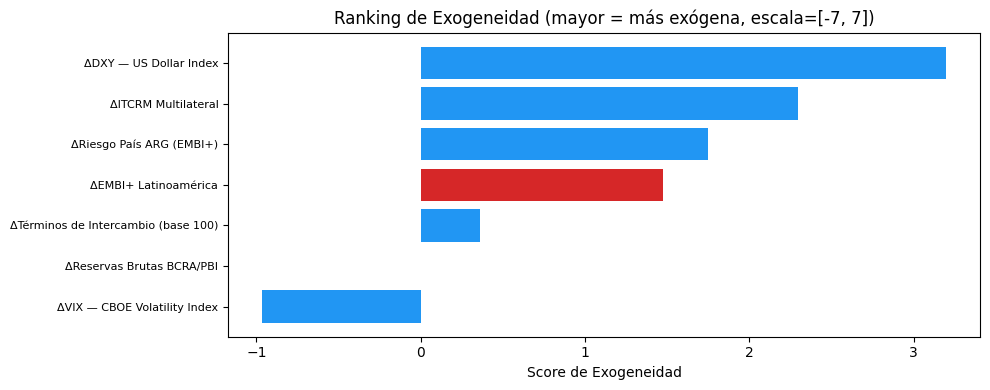

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# 7.3  RANKING DE EXOGENEIDAD
# ═══════════════════════════════════════════════════════════════════════════

print('═'*70)
print('7.3  RANKING DE EXOGENEIDAD')
print('═'*70)

if df_ardl_full.empty:
    print('⚠️  df_ardl_full vacio. Ejecutar sección 7.2 primero.')
    ranking_exogeneidad = pd.Series(dtype=float)
else:
    # Solo modelos con residuos de ruido blanco Y BIC mejor que la media
    df_rb = df_ardl_full[df_ardl_full['resid_ruido_blanco'] == True].copy()
    _bic_media = df_rb['BIC'].mean() if not df_rb.empty else np.nan
    df_valid = df_rb[df_rb['BIC'] < _bic_media].copy() if not df_rb.empty else df_rb.copy()
    
    if df_valid.empty:
        print('⚠️  Ningún modelo cumple ambos filtros. Usando modelos con ruido blanco.')
        df_valid = df_rb.copy()
        if df_valid.empty:
            print('⚠️  Ningún modelo tiene residuos de ruido blanco. Usando todos los modelos.')
            df_valid = df_ardl_full.copy()
    
    n_vars_total = len(ALL_VARS)
    scores = {}
    
    for _v in ALL_VARS:
        # ── Como Y (explicada): promedio de -R²_adj ──
        mask_y = df_valid['y_var'] == _v
        count_y = mask_y.sum()
        sum_y = (-df_valid.loc[mask_y, 'R2_adj']).sum() if count_y > 0 else 0
        avg_y = sum_y / count_y if count_y > 0 else 0
        
        # ── Como X (explicativa): p-value minimo por variable ──
        mask_x = df_valid['x_vars'].apply(lambda xv: _v in xv if isinstance(xv, (list, tuple)) else False)
        count_x = mask_x.sum()
        
        sum_x = 0
        if count_x > 0:
            for _, row in df_valid[mask_x].iterrows():
                _pvals = row['pvalues']
                # Buscar minimo p-value de esta variable entre sus rezagos
                _var_pvals = []
                for _key, _pval in _pvals.items():
                    if _key.startswith(f'{_v}_L'):
                        _var_pvals.append(_pval)
                
                if _var_pvals:
                    _p = min(_var_pvals)
                    if _p < 0.01:
                        sum_x += 1
                    elif _p > 0.05:
                        sum_x += 0
                    else:
                        sum_x += (0.05 - _p) / 0.04
        
        avg_x = sum_x / count_x if count_x > 0 else 0
        
        score = avg_x + avg_y
        scores[_v] = score * n_vars_total
    
    ranking_exogeneidad = pd.Series(scores).sort_values(ascending=False)
    
    print(f'\nModelos validos (ruido blanco + BIC < media): {len(df_valid)} de {len(df_ardl_full)}')
    print(f'Variables analizadas: {n_vars_total}')
    print('\n' + '═'*70)
    print('  RANKING DE EXOGENEIDAD')
    print('═'*70)
    for i, (v, s) in enumerate(ranking_exogeneidad.items(), 1):
        label = COL_LABEL.get(v, v)
        print(f'  [{i:>2}]  {label:<55}  score={s:.4f}')
    print('═'*70)
    
    # DataFrame del ranking
    ranking_df = pd.DataFrame({
        'variable': [COL_LABEL.get(v, v) for v in ranking_exogeneidad.index],
        'score': ranking_exogeneidad.values,
        'rank': range(1, len(ranking_exogeneidad) + 1),
    })
    display(ranking_df)
    
    # Gráfico de barras horizontales
    fig, ax = plt.subplots(figsize=(10, max(4, len(ranking_exogeneidad) * 0.5)))
    labels = [COL_LABEL.get(v, v)[:45] for v in ranking_exogeneidad.index]
    colors = ['#2196F3' if v != Y_SAFE else '#d62728' for v in ranking_exogeneidad.index]
    ax.barh(range(len(labels)), ranking_exogeneidad.values, color=colors)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Score de Exogeneidad')
    ax.set_title(f'Ranking de Exogeneidad (mayor = más exógena, escala=[-{n_vars_total}, {n_vars_total}])')
    ax.invert_yaxis()
    plt.tight_layout()
# ═════════════════════════════════════════════════════════════════
    #  CUADRO: PODER EXPLICATIVO DE CADA VARIABLE SOBRE LAS DEMÁS
    # ═════════════════════════════════════════════════════════════════
    print('\n' + '═'*70)
    print('  CUADRO: PODER EXPLICATIVO POR PAR (Y → X)')
    print('═'*70)
    
    _explanatory_rows = []
    for _y in ALL_VARS:
        _row = {'Variable Y': COL_LABEL.get(_y, _y)}
        for _x in ALL_VARS:
            if _x == _y:
                continue
            # Modelos donde Y es dependiente y X es explicativa
            _mask = (df_valid['y_var'] == _y) & (df_valid['x_vars'].apply(lambda xv: _x in xv if isinstance(xv, (list, tuple)) else False))
            _subset = df_valid[_mask]
            
            _min_pvals = []
            for _, _rmodel in _subset.iterrows():
                _pv = _rmodel['pvalues']
                _x_pvals = [_pv[k] for k in _pv if k.startswith(f'{_x}_L')]
                if _x_pvals:
                    _min_pvals.append(min(_x_pvals))
            
            if _min_pvals:
                _pct_sig = sum(1 for p in _min_pvals if p < 0.05) / len(_min_pvals) * 100
                _avg_p = sum(_min_pvals) / len(_min_pvals)
                _best_p = min(_min_pvals)
            else:
                _pct_sig = _avg_p = _best_p = np.nan
            
            _row[f'{COL_LABEL.get(_x, _x)}_%_sig'] = _pct_sig
            _row[f'{COL_LABEL.get(_x, _x)}_avg_p'] = _avg_p
            _row[f'{COL_LABEL.get(_x, _x)}_best_p'] = _best_p
        
        _explanatory_rows.append(_row)
    
    _df_explanatory = pd.DataFrame(_explanatory_rows)
    display(_df_explanatory.round(4))
    
    # ═════════════════════════════════════════════════════════════════
    #  DOS RANKINGS JERÁRQUICOS SEPARADOS
    # ═════════════════════════════════════════════════════════════════
    print('\n' + '═'*70)
    print('  RANKING 1 — SOLO P-VALUES (como X)')
    print('═'*70)
    
    _scores_p = {}
    for _v in ALL_VARS:
        _mask_x = df_valid['x_vars'].apply(lambda xv: _v in xv if isinstance(xv, (list, tuple)) else False)
        _count_x = _mask_x.sum()
        _sum_x = 0
        if _count_x > 0:
            for _, _row in df_valid[_mask_x].iterrows():
                _pvals = _row['pvalues']
                _var_pvals = [_pvals[k] for k in _pvals if k.startswith(f'{_v}_L')]
                if _var_pvals:
                    _p = min(_var_pvals)
                    if _p < 0.01:
                        _sum_x += 1
                    elif _p > 0.05:
                        _sum_x += 0
                    else:
                        _sum_x += (0.05 - _p) / 0.04
        _avg_x = _sum_x / _count_x if _count_x > 0 else 0
        _scores_p[_v] = _avg_x * n_vars_total
    
    _ranking_p = pd.Series(_scores_p).sort_values(ascending=False)
    for i, (v, s) in enumerate(_ranking_p.items(), 1):
        print(f'  [{i:>2}]  {COL_LABEL.get(v, v):<55}  score={s:.4f}')
    
    print('\n' + '═'*70)
    print('  RANKING 2 — SOLO R² AJUSTADO (como Y)')
    print('═'*70)
    
    _scores_r2 = {}
    for _v in ALL_VARS:
        _mask_y = df_valid['y_var'] == _v
        _count_y = _mask_y.sum()
        _sum_y = (-df_valid.loc[_mask_y, 'R2_adj']).sum() if _count_y > 0 else 0
        _avg_y = _sum_y / _count_y if _count_y > 0 else 0
        _scores_r2[_v] = _avg_y * n_vars_total
    
    _ranking_r2 = pd.Series(_scores_r2).sort_values(ascending=False)
    for i, (v, s) in enumerate(_ranking_r2.items(), 1):
        print(f'  [{i:>2}]  {COL_LABEL.get(v, v):<55}  score={s:.4f}')
    print('═'*70)
    plt.show()


### 7.4 GETS — General-to-Specific

> Para cada variable como dependiente, partir de un GUM (General Unrestrictive Model)
> con TODAS las variables explicativas, y eliminar secuencialmente la menos significativa
> hasta que todas las restantes tengan p < α. El camino de eliminación revela la estructura causal.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 7.4  GETS — General-to-Specific (GUM → eliminación secuencial)
# ═══════════════════════════════════════════════════════════════════════════
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

print('═'*70)
print('7.4  GETS — GENERAL-TO-SPECIFIC')
print('═'*70)

def _estimar_ardl_gets(y_var, x_vars_list, df_data, bj_lags_dict,
                        max_lags_dep, nivel_sig):
    """
    Estima un ARDL y devuelve (modelo, residuo, p-values dict, es_ruido_blanco).
    """
    try:
        _df_r = pd.DataFrame({'y': df_data[y_var]})
        for lag in range(1, max_lags_dep + 1):
            _df_r[f'{y_var}_L{lag}'] = df_data[y_var].shift(lag)
        for _xv in x_vars_list:
            _lags = bj_lags_dict.get((y_var, _xv), {}).get('lags', [0, 1])
            for lag in _lags:
                _df_r[f'{_xv}_L{lag}'] = df_data[_xv].shift(lag)
        _df_r = _df_r.dropna()
        if len(_df_r) < 20:
            return None, None, {}, False
        _yv = _df_r['y']
        _Xv = _df_r.drop(columns=['y'])
        _Xv = sm.add_constant(_Xv)
        if np.linalg.matrix_rank(_Xv) < _Xv.shape[1]:
            return None, None, {}, False
        _mod = sm.OLS(_yv, _Xv).fit()
        _res = _mod.resid
        _pvals = {}
        for _col in _Xv.columns:
            if _col == 'const':
                continue
            _pvals[_col] = _mod.pvalues[_col]
        # Ruido blanco
        _lb_lags = min(10, len(_res) // 5)
        try:
            _lb_res = acorr_ljungbox(_res, lags=_lb_lags, return_df=True)
            _lb_p = float(_lb_res['lb_pvalue'].iloc[-1])
        except Exception:
            _lb_p = np.nan
        _is_white = (not np.isnan(_lb_p)) and (_lb_p >= 0.05)
        return _mod, _res, _pvals, _is_white
    except Exception:
        return None, None, {}, False


def _min_pval_de_variable(pvals_dict, var_safe):
    """Devuelve el mínimo p-value de todos los rezagos de una variable."""
    _found = [_pvals[k] for k in _pvals if k.startswith(f'{var_safe}_L')]
    return min(_found) if _found else 1.0


print(f'\nVariables disponibles: {len(ALL_VARS)}')
print(f'Nivel de significancia GETS: α = {GETS_ALPHA}')

_y_vars_gets = ALL_VARS if TODAS_COMO_DEPENDIENTE else [Y_SAFE]
gets_path_rows = []
gets_final_rows = []

for _yi, _yvar in enumerate(_y_vars_gets):
    _y_lbl = COL_LABEL.get(_yvar, _yvar)
    _other_vars = [v for v in ALL_VARS if v != _yvar]

    # ── PASO 0: Estimar el GUM (General Unrestrictive Model) ──────────
    _current_vars = list(_other_vars)
    _mod, _res, _pvals, _is_white = _estimar_ardl_gets(
        _yvar, _current_vars, df_safe, bj_lags, MAX_LAGS_DEP, GETS_ALPHA
    )

    if _mod is None:
        print(f'  [{_yi+1:>2}/{len(_y_vars_gets)}] {_y_lbl[:40]:<40} → GUM falló, saltando')
        continue

    print(f'  [{_yi+1:>2}/{len(_y_vars_gets)}] {_y_lbl[:40]:<40} → GUM: {len(_current_vars)} vars, '
          f'R²={_mod.rsquared_adj:.4f}, BIC={_mod.bic:.1f}')

    # Registrar GUM como paso 0
    gets_path_rows.append({
        'y_var': _yvar, 'step': 0, 'action': 'GUM',
        'var_removed': '', 'pval_removed': 0.0,
        'R2_adj': _mod.rsquared_adj, 'AIC': _mod.aic, 'BIC': _mod.bic,
        'n_vars': len(_current_vars), 'white_noise': _is_white
    })

    # ── LOOP GETS: Eliminar la menos significativa en cada paso ────────
    _step = 0
    while len(_current_vars) > 0:
        _step += 1
        # Encontrar la variable con mayor p-value (menos significativa)
        _pvar = {}
        for _v in _current_vars:
            _pvar[_v] = _min_pval_de_variable(_pvals, _v)

        _worst_var = max(_pvar, key=_pvar.get)
        _worst_p = _pvar[_worst_var]

        # Condición de parada: todas significativas
        if _worst_p < GETS_ALPHA:
            break

        # Eliminar la peor variable
        _current_vars.remove(_worst_var)

        if len(_current_vars) == 0:
            gets_path_rows.append({
                'y_var': _yvar, 'step': _step, 'action': 'eliminated → 0 vars',
                'var_removed': COL_LABEL.get(_worst_var, _worst_var),
                'pval_removed': _worst_p,
                'R2_adj': np.nan, 'AIC': np.nan, 'BIC': np.nan,
                'n_vars': 0, 'white_noise': False
            })
            break

        # Re-estimar sin la variable eliminada
        _mod2, _res2, _pvals2, _is_white2 = _estimar_ardl_gets(
            _yvar, _current_vars, df_safe, bj_lags, MAX_LAGS_DEP, GETS_ALPHA
        )

        if _mod2 is None:
            gets_path_rows.append({
                'y_var': _yvar, 'step': _step, 'action': 'failed after removal',
                'var_removed': COL_LABEL.get(_worst_var, _worst_var),
                'pval_removed': _worst_p,
                'R2_adj': np.nan, 'AIC': np.nan, 'BIC': np.nan,
                'n_vars': len(_current_vars) + 1, 'white_noise': False
            })
            break

        _pvals = _pvals2
        gets_path_rows.append({
            'y_var': _yvar, 'step': _step, 'action': 'eliminated',
            'var_removed': COL_LABEL.get(_worst_var, _worst_var),
            'pval_removed': _worst_p,
            'R2_adj': _mod2.rsquared_adj, 'AIC': _mod2.aic, 'BIC': _mod2.bic,
            'n_vars': len(_current_vars), 'white_noise': _is_white2
        })

    # ── Registrar modelo final GETS ────────────────────────────────────
    if _mod is not None:
        _vars_finales = [COL_LABEL.get(v, v) for v in _current_vars]
        gets_final_rows.append({
            'y_var': COL_LABEL.get(_yvar, _yvar),
            'n_vars_final': len(_current_vars),
            'vars_finales': ', '.join(_vars_finales),
            'R2_adj': _mod.rsquared_adj, 'AIC': _mod.aic, 'BIC': _mod.bic,
            'white_noise': _is_white
        })
        print(f'          → Final: {len(_current_vars)} vars, '
              f'R²={_mod.rsquared_adj:.4f}, BIC={_mod.bic:.1f}, '
              f'vars={_vars_finales}')

df_gets_path = pd.DataFrame(gets_path_rows)
df_gets_final = pd.DataFrame(gets_final_rows)

print(f'\n✅ GETS completado: {len(df_gets_final)} modelos finales')
if not df_gets_path.empty:
    print(f'   Pasos totales de eliminación: {len(df_gets_path[df_gets_path["action"]=="eliminated"])}')
if not df_gets_final.empty:
    display(df_gets_final[['y_var','n_vars_final','vars_finales','R2_adj','BIC','white_noise']])


## 8. Verificación VAR del Orden Jerárquico

### 8.1 Selección del orden del VAR

> Evaluar criterios AIC/BIC/HQ para seleccionar el orden óptimo.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.1  ESTIMACIÓN VAR — TODAS LAS COMBINACIONES + TODAS LAS PERMUTACIONES
#      Sin orden Cholesky fijo: se prueban todas las permutaciones posibles
#      de cada subconjunto de variables.
# ═══════════════════════════════════════════════════════════════════════════
from statsmodels.tsa.api import VAR as _VAR_est
from statsmodels.stats.diagnostic import acorr_ljungbox as _lb_var
from itertools import combinations as _comb_var, permutations as _perm_var
from scipy.stats import norm as _norm_var

print('═'*70)
print('8.1  ESTIMACIÓN VAR — TODAS LAS COMBINACIONES + PERMUTACIONES')
print('═'*70)

# ── Variables disponibles: todas (sin orden predefinido) ──────────────────────
_vars_est = [v for v in ALL_VARS if v in X_SAFE_EST or v == Y_SAFE]
_others   = [v for v in _vars_est if v != Y_SAFE]
_max_k    = len(_others) if MAX_VARS_POR_MODELO is None else min(MAX_VARS_POR_MODELO, len(_others))

_combos_var = []
for _k in range(1, _max_k + 1):
    for _c in _comb_var(_others, _k):
        _combos_var.append(list(_c))

if MAX_COMBINACIONES is not None and len(_combos_var) > MAX_COMBINACIONES:
    random.seed(SEMILLA)
    _combos_var = random.sample(_combos_var, MAX_COMBINACIONES)

print(f'Variables disponibles:  {len(_vars_est)}')
print(f'Combinaciones de X:     {len(_combos_var)}')
print(f'Max permutaciones Cholesky por modelo: {MAX_PERMUTACIONES_VAR}')
print(f'Horizonte IRF: {HORIZONTE_IRF}')

# ── Loop de estimación ─────────────────────────────────────────────────────
var_results  = []
_n_ok = _n_fail = _total_perms = 0

for _ci, _x_combo in enumerate(_combos_var):
    try:
        _all_v = [Y_SAFE] + list(_x_combo)
        _K     = len(_all_v)

        # Generar todas las permutaciones de orden Cholesky
        _all_perms = list(_perm_var(_all_v))
        _n_perms   = len(_all_perms)
        if _n_perms > MAX_PERMUTACIONES_VAR:
            random.seed(SEMILLA + _ci)
            _all_perms = random.sample(_all_perms, MAX_PERMUTACIONES_VAR)
            _n_perms   = MAX_PERMUTACIONES_VAR

        for _perm in _all_perms:
            _ordered = list(_perm)
            _df_var  = df_safe[_ordered].dropna()
            _T       = len(_df_var)

            if _T < 30:
                continue

            _max_p = min(MAX_LAGS_VAR, max(1, int((_T - 1) / (_K + 1))))
            _model = _VAR_est(_df_var)

            for _p in range(1, _max_p + 1):
                try:
                    _fit = _model.fit(_p)

                    # ── Ljung-Box sobre residuos de Y ──────────────────
                    _y_idx   = _ordered.index(Y_SAFE)
                    _resid_y = _fit.resid.iloc[:, _y_idx].values
                    _lb_lags = min(10, len(_resid_y) // 5)
                    try:
                        _lb_res = _lb_var(_resid_y, lags=_lb_lags, return_df=True)
                        _lb_p   = float(_lb_res['lb_pvalue'].iloc[-1])
                    except Exception:
                        _lb_p = np.nan

                    _is_white = (not np.isnan(_lb_p)) and (_lb_p >= 0.05)
                    _stable   = _fit.is_stable(verbose=False)

                    # ── R² ajustado para Y ─────────────────────────────
                    _ss_res  = np.sum(_resid_y**2)
                    _y_vals  = _df_var[Y_SAFE].values[_p:]
                    _ss_tot  = np.sum((_y_vals - np.mean(_y_vals))**2)
                    _r2      = 1 - _ss_res / _ss_tot if _ss_tot > 0 else 0
                    _n_par   = _K * _p + 1
                    _r2_adj  = 1 - (1 - _r2) * (len(_y_vals) - 1) / max(1, len(_y_vals) - _n_par - 1)

                    # ── IRFs ortogonalizadas: orth_irfs[h, response, shock] ──
                    _irf_data = {}
                    try:
                        _irf_obj     = _fit.irf(periods=HORIZONTE_IRF)
                        _orth_irfs   = _irf_obj.orth_irfs          # (periods+1, K, K)
                        _orth_stderr = _irf_obj.stderr(orth=True)  # (periods+1, K, K)
                    except Exception:
                        _orth_irfs   = None
                        _orth_stderr = None

                    if _orth_irfs is not None:
                        for _vi, _vx in enumerate(_ordered):
                            for _h in range(HORIZONTE_IRF + 1):
                                # response = Y_SAFE (_y_idx), shock = _vx (_vi)
                                _imp = float(_orth_irfs[_h, _y_idx, _vi])
                                _irf_data[f'irf_{_vx}_h{_h}'] = _imp
                                try:
                                    _se  = float(_orth_stderr[_h, _y_idx, _vi]) if _orth_stderr is not None else np.nan
                                    _z   = abs(_imp / _se) if (_se is not None and _se > 0) else 0.0
                                    _irf_data[f'irfpval_{_vx}_h{_h}'] = float(2 * (1 - _norm_var.cdf(_z)))
                                except Exception:
                                    _irf_data[f'irfpval_{_vx}_h{_h}'] = np.nan

                    _row = {
                        'x_vars'            : tuple(_x_combo),
                        'cholesky_order'    : tuple(_ordered),
                        'n_vars'            : _K,
                        'T'                 : _T,
                        'max_p_allowed'     : _max_p,
                        'p_selected'        : _p,
                        'R2_adj'            : _r2_adj,
                        'AIC'               : float(_fit.aic),
                        'BIC'               : float(_fit.bic),
                        'HQ'                : float(_fit.hqic),
                        'LB_pvalue'         : _lb_p,
                        'stable'            : _stable,
                        'resid_ruido_blanco': _is_white,
                    }
                    _row.update(_irf_data)
                    var_results.append(_row)
                    _n_ok += 1
                except Exception:
                    _n_fail += 1
                    continue

        _total_perms += _n_perms

    except Exception:
        _n_fail += 1
        continue

    if (_ci + 1) % 10 == 0:
        print(f'  {_ci+1}/{len(_combos_var)} combos ... OK={_n_ok}  fail={_n_fail}  perms={_total_perms}')

df_var_full = pd.DataFrame(var_results)
print(f'
✅ Modelos VAR estimados: {len(df_var_full)}')
print(f'   Permutaciones Cholesky totales: {_total_perms}')
if not df_var_full.empty:
    _n_w = df_var_full['resid_ruido_blanco'].sum()
    _n_s = df_var_full['stable'].sum()
    print(f'   Ruido blanco: {_n_w} ({_n_w/len(df_var_full)*100:.1f}%)')
    print(f'   Estables:     {_n_s} ({_n_s/len(df_var_full)*100:.1f}%)')
    print(f'   BIC medio:    {df_var_full["BIC"].mean():.2f}')
    print(f'   R² adj medio: {df_var_full["R2_adj"].mean():.4f}')
    _perms_per_combo = df_var_full.groupby('x_vars')['cholesky_order'].nunique()
    print(f'   Permutaciones por combo: media={_perms_per_combo.mean():.1f}, '
          f'min={_perms_per_combo.min()}, max={_perms_per_combo.max()}')


### 8.2 FEVD — Descomposición de Varianza del Error de Pronóstico

> Para cada modelo con residuos de ruido blanco y BIC < media,
> calcular la FEVD y registrar qué variables explican más varianza del EMBI.
> Se muestran los top 5 modelos según BIC. Se usa el orden Cholesky de cada modelo.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.2  FEVD — TOP 5 MODELOS (ruido blanco + BIC < media)
# ═══════════════════════════════════════════════════════════════════════════

print('═'*70)
print('8.2  FEVD — DESCOMPOSICIÓN DE VARIANZA DEL ERROR DE PRONÓSTICO')
print('═'*70)

if 'df_var_full' not in globals() or df_var_full.empty:
    print('⚠️  Sin modelos VAR. Ejecutar sección 8.1.')
else:
    # ── Filtrar: ruido blanco + estable + BIC < media ──────────────────
    _df_ok = df_var_full[
        (df_var_full['resid_ruido_blanco'] == True) &
        (df_var_full['stable'] == True)
    ].copy()

    if _df_ok.empty:
        print('⚠️  Ningún modelo pasa ruido blanco + estabilidad.')
        print('    Usando todos los modelos estables como fallback.')
        _df_ok = df_var_full[df_var_full['stable'] == True].copy()

    if not _df_ok.empty:
        _bic_mean = _df_ok['BIC'].mean()
        _df_good = _df_ok[_df_ok['BIC'] < _bic_mean].copy()
        if _df_good.empty:
            _df_good = _df_ok.copy()
        _df_good = _df_good.sort_values('BIC').head(5).reset_index(drop=True)

        print(f'Modelos con ruido blanco + estables: {len(_df_ok)}')
        print(f'BIC medio: {_bic_mean:.2f}')
        print(f'Top 5 por BIC (de {len(_df_ok)} filtrados):\n')

        FEVD_HORIZONTE = 24
        _COLORS_FEVD = plt.cm.tab10.colors

        for _rank, _row in _df_good.iterrows():
            _ordered = list(_row['cholesky_order'])
            _p = int(_row['p_selected'])
            _df_v = df_safe[_ordered].dropna()

            try:
                _fit = _VAR_est(_df_v).fit(_p)
                _fevd = _fit.fevd(FEVD_HORIZONTE)
            except Exception as _e:
                print(f'  Error FEVD modelo {_rank+1}: {_e}')
                continue

            _y_idx = _ordered.index(Y_SAFE)
            _decomp = _fevd.decomp

            # Detectar la shape real de decomp y extraer correctamente
            _n_periods = _decomp.shape[1] if _decomp.ndim == 3 else _decomp.shape[0]

            # FEVD de Y: la shape es (K, periods, K) en statsmodels
            # _decomp[y_idx] tiene shape (periods, K)
            if _decomp.ndim == 3:
                _fevd_y = _decomp[_y_idx]  # (periods, K)
            else:
                _fevd_y = _decomp  # caso raro, asumir que ya es (periods, K)

            _labels_v = [COL_LABEL.get(v, v)[:25] for v in _ordered]
            _vars_str = ', '.join([COL_LABEL.get(v, v)[:20] for v in _row['x_vars']])

            print(f'\n── Modelo {_rank+1}: BIC={_row["BIC"]:.1f}  '
                  f'p={_p}  R²adj={_row["R2_adj"]:.3f}  '
                  f'LB_p={_row["LB_pvalue"]:.3f}')
            print(f'   Vars: {_vars_str}')
            print(f'   Orden Cholesky: {" → ".join(_labels_v)}')

            # ── Tabla FEVD a horizontes seleccionados ──────────────────
            _horizons = [1, 3, 6, 12, min(FEVD_HORIZONTE, _n_periods)]
            _horizons = sorted(set(h for h in _horizons if h <= _n_periods))
            _fevd_table = pd.DataFrame(
                {f'h={h}': _fevd_y[h-1] for h in _horizons},
                index=_labels_v
            ).T
            print(_fevd_table.round(4).to_string())

            # ── Gráfico de barras apiladas ─────────────────────────────
            _n_h = min(FEVD_HORIZONTE, _n_periods)
            fig, ax = plt.subplots(figsize=(12, 5))
            _x_pos = np.arange(_n_h)
            _bottom = np.zeros(_n_h)

            for _j, _lbl in enumerate(_labels_v):
                _vals = _fevd_y[:_n_h, _j]
                ax.bar(_x_pos, _vals, bottom=_bottom,
                       label=_lbl, color=_COLORS_FEVD[_j % len(_COLORS_FEVD)],
                       edgecolor='white', linewidth=0.3)
                _bottom += _vals

            ax.set_xlabel('Horizonte (períodos)', fontsize=10)
            ax.set_ylabel('Proporción de varianza explicada', fontsize=10)
            ax.set_title(
                f'FEVD del {COL_LABEL.get(Y_SAFE, Y_SAFE)[:30]} — '
                f'Modelo {_rank+1} (BIC={_row["BIC"]:.0f}, p={_p})',
                fontsize=11
            )
            ax.set_xticks(_x_pos[::2])
            ax.set_xticklabels([str(h+1) for h in _x_pos[::2]])
            ax.set_ylim(0, 1.05)
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
            plt.tight_layout()
            plt.show()

        print('\n' + '═'*70)
        print('  RESUMEN FEVD h=12 — TOP 5 MODELOS')
        print('═'*70)
    else:
        print('⚠️  Ningún modelo VAR es estable.')


### 8.3 Test de Causalidad de Granger — TODOS los pares de variables

> Para cada modelo VAR (ruido blanco + estable + BIC < media), testear la causalidad
> de Granger para TODOS los pares ordenados (V_i → V_j). Registrar el estadístico F
> y el p-value en un DataFrame. Esto permite construir la matriz de causalidad completa.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.3  TEST DE CAUSALIDAD DE GRANGER — TODOS LOS PARES × TODOS LOS MODELOS
# ═══════════════════════════════════════════════════════════════════════════
from itertools import permutations as _perm_granger

print('═'*70)
print('8.3  TEST DE CAUSALIDAD DE GRANGER — TODOS LOS PARES')
print('═'*70)

if 'df_var_full' not in globals() or df_var_full.empty:
    print('⚠️  Sin modelos VAR. Ejecutar sección 8.1.')
else:
    # ── Filtrar: ruido blanco + estable + BIC < media ──────────────────
    _df_ok = df_var_full[
        (df_var_full['resid_ruido_blanco'] == True) &
        (df_var_full['stable'] == True)
    ].copy()

    if _df_ok.empty:
        print('⚠️  Ningún modelo pasa filtros. Usando todos.')
        _df_ok = df_var_full.copy()

    _bic_mean = _df_ok['BIC'].mean()
    _df_good = _df_ok[_df_ok['BIC'] < _bic_mean].copy()
    if _df_good.empty:
        _df_good = _df_ok.copy()

    # Para evitar explosión, tomar top N modelos por BIC (máx 50)
    _N_MODELOS_GRANGER = min(50, len(_df_good))
    _df_good = _df_good.sort_values('BIC').head(_N_MODELOS_GRANGER).reset_index(drop=True)

    print(f'Modelos evaluados: {len(_df_good)} (top {len(_df_good)} por BIC de {len(_df_ok)} filtrados)')
    print(f'BIC medio (filtrados): {_bic_mean:.2f}')

    # ── Recopilar F-statistics para todos los pares ────────────────────
    granger_all_rows = []
    _n_granger_ok = 0

    for _mi, _row in _df_good.iterrows():
        _ordered = list(_row['cholesky_order'])
        _p = int(_row['p_selected'])
        _df_v = df_safe[_ordered].dropna()

        try:
            _fit = _VAR_est(_df_v).fit(_p)
        except Exception:
            continue

        # Para cada par ordenado (V_i → V_j)
        for _vi, _vj in _perm_granger(_ordered, 2):
            try:
                _res = _fit.test_causality(caused=_vj, causing=_vi, kind='wald')
                _f_stat = float(_res.test_statistic) if hasattr(_res, 'test_statistic') else np.nan
                _p_val = float(_res.pvalue)
            except Exception:
                _f_stat = np.nan
                _p_val = np.nan

            granger_all_rows.append({
                'model_idx': _mi,
                'causing_var': COL_LABEL.get(_vi, _vi),
                'caused_var': COL_LABEL.get(_vj, _vj),
                'causing_safe': _vi,
                'caused_safe': _vj,
                'F_stat': _f_stat,
                'p_value': _p_val,
                'p_selected': _p,
                'BIC': _row['BIC'],
                'cholesky_order': tuple(_ordered),
            })
            _n_granger_ok += 1

        if (_mi + 1) % 20 == 0:
            print(f'  {_mi+1}/{len(_df_good)} modelos procesados ... tests={_n_granger_ok}')

    df_granger_all = pd.DataFrame(granger_all_rows)
    print(f'\n✅ Tests de Granger completados: {len(df_granger_all)}')

    if not df_granger_all.empty:
        # ── Estadísticas por par ───────────────────────────────────────
        _pairs_summary = df_granger_all.groupby(['causing_var', 'caused_var']).agg(
            F_stat_mean=('F_stat', 'mean'),
            F_stat_median=('F_stat', 'median'),
            F_stat_max=('F_stat', 'max'),
            p_val_mean=('p_value', 'mean'),
            p_val_median=('p_value', 'median'),
            pct_sig=('p_value', lambda x: (x < 0.05).mean() * 100),
            n_models=('p_value', 'count'),
        ).round(4)

        print(f'\nPares únicos: {len(_pairs_summary)}')
        print(f'Modelos por par (media): {_pairs_summary["n_models"].mean():.1f}')

        # ── Mostrar top pares más significativos ───────────────────────
        print('\n' + '═'*70)
        print('  TOP PARES GRANGER (por % de modelos con p < 0.05)')
        print('═'*70)
        _top_pairs = _pairs_summary.sort_values('pct_sig', ascending=False).head(20)
        display(_top_pairs)

        # ── Resumen para EMBI como variable causada ────────────────────
        _embi_lbl = COL_LABEL.get(Y_SAFE, Y_SAFE)
        _embi_causes = df_granger_all[
            df_granger_all['caused_var'] == _embi_lbl
        ].groupby('causing_var').agg(
            F_mean=('F_stat', 'mean'),
            p_mean=('p_value', 'mean'),
            pct_sig=('p_value', lambda x: (x < 0.05).mean() * 100),
        ).sort_values('pct_sig', ascending=False).round(4)

        print(f'\n── Causalidad sobre {_embi_lbl[:40]} (X → Y) ──')
        display(_embi_causes)


### 8.4 Matriz de dispersión de estadísticos F de Granger

> Scatter plot matrix (pairplot) de los estadísticos F promedio entre todos los pares
> de variables. Permite visualizar la dinámica de significación de los tests de Granger
> a través de las diferentes identificaciones del VAR estructural (permutaciones Cholesky).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.4  MATRIZ DE DISPERSIÓN DE F-STATISTICS DE GRANGER
# ═══════════════════════════════════════════════════════════════════════════

print('═'*70)
print('8.4  MATRIZ DE DISPERSIÓN DE F-STATISTICS DE GRANGER')
print('═'*70)

if 'df_granger_all' not in globals() or df_granger_all.empty:
    print('⚠️  Sin datos de Granger. Ejecutar sección 8.3.')
else:
    # ── Construir matriz F-stat median por par ────────────────────────
    _f_pivot = df_granger_all.pivot_table(
        index='causing_var', columns='caused_var',
        values='F_stat', aggfunc='median'
    )

    # ── Construir matriz de % significancia ───────────────────────────
    _sig_pivot = df_granger_all.pivot_table(
        index='causing_var', columns='caused_var',
        values='p_value', aggfunc=lambda x: (x < 0.05).mean() * 100
    )

    _var_names = list(_f_pivot.index)
    _n_vars = len(_var_names)

    # ── 1. Heatmap de F-statistics medianos ────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(max(16, _n_vars * 2.5), max(8, _n_vars * 1.2)))

    # F-stat median
    ax1 = axes[0]
    _f_vals = _f_pivot.values.astype(float)
    _im1 = ax1.imshow(_f_vals, cmap='YlOrRd', aspect='auto')
    ax1.set_xticks(range(_n_vars))
    ax1.set_yticks(range(_n_vars))
    _short_names = [v[:20] for v in _var_names]
    ax1.set_xticklabels(_short_names, rotation=45, ha='right', fontsize=7)
    ax1.set_yticklabels(_short_names, fontsize=7)
    ax1.set_title('F-statistic mediano de Granger\n(causing=fila → caused=columna)', fontsize=10)
    for _i in range(_n_vars):
        for _j in range(_n_vars):
            if _i != _j:
                _val = _f_vals[_i, _j]
                if not np.isnan(_val):
                    ax1.text(_j, _i, f'{_val:.1f}', ha='center', va='center', fontsize=6,
                             color='white' if _val > np.nanmax(_f_vals) * 0.6 else 'black')
    plt.colorbar(_im1, ax=ax1, fraction=0.046, pad=0.04)

    # % significancia
    ax2 = axes[1]
    _sig_vals = _sig_pivot.values.astype(float)
    _im2 = ax2.imshow(_sig_vals, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    ax2.set_xticks(range(_n_vars))
    ax2.set_yticks(range(_n_vars))
    ax2.set_xticklabels(_short_names, rotation=45, ha='right', fontsize=7)
    ax2.set_yticklabels(_short_names, fontsize=7)
    ax2.set_title('% de modelos con p < 0.05\n(causing=fila → caused=columna)', fontsize=10)
    for _i in range(_n_vars):
        for _j in range(_n_vars):
            if _i != _j:
                _val = _sig_vals[_i, _j]
                if not np.isnan(_val):
                    ax2.text(_j, _i, f'{_val:.0f}%', ha='center', va='center', fontsize=7,
                             fontweight='bold' if _val > 50 else 'normal')
    plt.colorbar(_im2, ax=ax2, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # ── 2. Scatter plot matrix: F-stat de Granger entre pares ─────────
    # Para cada variable como "caused", scatter de F-stats de todos los "causing"
    if _n_vars >= 2:
        fig, axes_sc = plt.subplots(
            _n_vars, _n_vars,
            figsize=(max(12, _n_vars * 2.5), max(10, _n_vars * 2.2)),
            squeeze=False
        )

        for _i, _caused in enumerate(_var_names):
            for _j, _causing in enumerate(_var_names):
                ax = axes_sc[_i, _j]
                if _i == _j:
                    # Diagonal: histograma de F-stats cuando esta variable es causada
                    _mask_diag = df_granger_all['caused_var'] == _caused
                    _f_diag = df_granger_all.loc[_mask_diag, 'F_stat'].dropna()
                    if len(_f_diag) > 0:
                        ax.hist(_f_diag, bins=15, color='#2196F3', alpha=0.7, edgecolor='white')
                        ax.axvline(x=_f_diag.median(), color='red', linestyle='--', linewidth=1)
                    ax.set_title(f'{_caused[:15]}', fontsize=6, pad=2)
                    ax.tick_params(labelsize=5)
                else:
                    # Off-diagonal: scatter de F-stat vs p-value para el par (causing, caused)
                    _mask_pair = (
                        (df_granger_all['causing_var'] == _causing) &
                        (df_granger_all['caused_var'] == _caused)
                    )
                    _pair_data = df_granger_all.loc[_mask_pair]
                    if len(_pair_data) > 0:
                        _x_vals = _pair_data['F_stat'].values
                        _y_vals = _pair_data['p_value'].values
                        _colors = ['#d62728' if p < 0.05 else '#1f77b4' for p in _y_vals]
                        ax.scatter(_x_vals, _y_vals, c=_colors, s=8, alpha=0.6)
                        ax.axhline(y=0.05, color='gray', linestyle=':', linewidth=0.8)
                    ax.set_xlim(left=0)
                    ax.set_ylim(-0.05, 1.05)
                    ax.tick_params(labelsize=5)

                # Labels solo en bordes
                if _i == _n_vars - 1:
                    ax.set_xlabel(_causing[:12], fontsize=5, rotation=45)
                if _j == 0:
                    ax.set_ylabel(_caused[:12], fontsize=5)

        fig.suptitle(
            'Scatter: F-stat vs p-value por par (rojo=p<0.05, azul=no sig.)\n'
            'Diagonal = distribución de F-stats cuando esa variable es causada',
            fontsize=10
        )
        plt.tight_layout()
        plt.show()

    # ── 3. Box plot: distribución de F-stats por par ───────────────────
    if not df_granger_all.empty:
        _top_n_pairs = min(20, len(_pairs_summary))
        _top_pairs_list = _pairs_summary.sort_values('F_stat_median', ascending=False).head(_top_n_pairs)
        _top_pairs_list = _top_pairs_list.index.tolist()  # lista de tuples (causing, caused)

        if _top_pairs_list:
            _box_data = []
            _box_labels = []
            for _cp in _top_pairs_list:
                _mask_b = (
                    (df_granger_all['causing_var'] == _cp[0]) &
                    (df_granger_all['caused_var'] == _cp[1])
                )
                _vals_b = df_granger_all.loc[_mask_b, 'F_stat'].dropna().values
                if len(_vals_b) > 0:
                    _box_data.append(_vals_b)
                    _box_labels.append(f'{_cp[0][:12]}→{_cp[1][:12]}')

            if _box_data:
                fig, ax = plt.subplots(figsize=(max(10, len(_box_data) * 0.8), 6))
                ax.boxplot(_box_data, labels=_box_labels, vert=True)
                ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.5)
                ax.set_ylabel('F-statistic de Granger', fontsize=10)
                ax.set_title('Distribución de F-statistics por par (top 20 por mediana)', fontsize=11)
                ax.tick_params(axis='x', rotation=45, labelsize=7)
                plt.tight_layout()
                plt.show()

    print('\n✅ Matrices de Granger generadas.')


## 9. Dinámica de Largo Plazo — VECM

### 9.1 Test de Cointegración de Johansen

> Usar las top N variables del ranking confirmado + EMBI.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 9.1-9.3  VECM — Dinámica de Largo Plazo
# ═══════════════════════════════════════════════════════════════════════════
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM as _VECM

print('═'*70)
print('9.  DINÁMICA DE LARGO PLAZO — VECM')
print('═'*70)

# TODO: Implementar secciones 9.1 a 9.3
# Ver guía: docs/guia_02b_analisis_completo.md, Secciones 9.1-9.3

print('Sección 9 pendiente de implementación.')


## 10. Síntesis y Conclusiones

> Tabla resumen final con ranking de exogeneidad, relaciones de largo plazo,
> y clasificación push factors vs pull factors idiosincráticos.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 10.  SÍNTESIS Y CONCLUSIONES
# ═══════════════════════════════════════════════════════════════════════════

print('═'*70)
print('10.  SÍNTESIS Y CONCLUSIONES')
print('═'*70)

# TODO: Implementar sección 10
# Ver guía: docs/guia_02b_analisis_completo.md, Sección 10

print('Sección 10 pendiente de implementación.')
